# MIND-FLOCK (revised v4) — full simulation & figures

End-to-end implementation of:

* **MIND-FLOCK** — confidence-weighted relational neighbourhood + many-body amplified weight $W_{ij}$ (γ-decoherence interpolation, Eq. 8)
* Three matched baselines:
  * **Metric Vicsek** — radius coupling, identity-blind
  * **Topological Vicsek** — $k$-nearest spatial neighbours, identity-blind
  * **Similarity-Vicsek** ($\gamma=1$) — relational neighbourhood retained, many-body amplification removed

**Two-group setup** (70 / 30 split), Power-Cauchy affinity ($p=2$, $\Delta=0.01$).

**Figures added (Appendix — MF vs Similarity-Vicsek head-to-head):**
* **Fig A1** — Order-parameter time series (global + per-group) with ±1 s.d. bands
* **Fig A2** — Convergence time $\tau(\theta)$ at three thresholds
* **Fig A3** — Small-group spatial compactness ($R_\text{gyr}$, $R_\text{max}$) over time
* **Table A1** — Numerical summary of every quantity


In [1]:
# ===== Imports & matplotlib defaults =====
import os, time, json, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import cm as mplcm
from numba import njit, prange
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Tuple, Dict

# Colab sometimes pins an older numba; accept either int64/intp.
print(f"NumPy   : {np.__version__}")
import numba; print(f"Numba   : {numba.__version__}")

mpl.rcParams.update({
    'figure.dpi': 110,
    'savefig.dpi': 200,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'axes.spines.right': False,
    'axes.spines.top': False,
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})

# Output directory (saved figures + numerical data)
OUT_DIR = "mindflock_outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# Reusable colours / labels for the four-way comparison
MODEL_COLORS = {
    'mindflock'           : '#1f4ea8',  # deep blue
    'similarity_vicsek'   : '#7e3ff2',  # purple
    'topological_vicsek'  : '#e25b00',  # orange
    'metric_vicsek'       : '#c11b1b',  # red
}
MODEL_LABELS = {
    'mindflock'           : 'MIND-FLOCK (γ=0)',
    'similarity_vicsek'   : 'Similarity-Vicsek (γ=1)',
    'topological_vicsek'  : 'Topological Vicsek',
    'metric_vicsek'       : 'Metric Vicsek',
}
GROUP_COLORS = ['#1f78b4', '#33a02c']


NumPy   : 2.3.5
Numba   : 0.62.1


## 1.  Initialisation primitives

Three identity sub-groups, scalar identities sampled from $\mathcal U(0.01,0.02)$, $\mathcal U(0.11,0.12)$, $\mathcal U(0.21,0.22)$. Domain side $L = \sqrt{N/\rho}$ at fixed density $\rho = 2.4$. Initial positions are 2-D Gaussian (centre $L/2$, $\sigma = 0.5 L$); initial headings are uniform on the circle. Per-agent speed dispersion $\lambda_i = \tfrac12(1+u_i)$, $u_i \sim \mathcal U[0,1)$.

In [2]:
# ===== Identity intervals & affinity =====

# Three identity intervals (paper §4.1)
ID_INTERVALS = ((0.010, 0.015), (0.022, 0.027))
N_GROUPS = 2

def init_identities(N, seed=0):
    rng = np.random.default_rng(seed)
    M_RATIO = 0.08 # 90/10 split
    m_count = int(N * M_RATIO)
    groups = np.zeros(N, dtype=np.int64)
    groups[m_count:] = 1
    identities = np.empty(N, dtype=np.float64)
    for g in range(N_GROUPS):
        m = (groups == g)
        lo, hi = ID_INTERVALS[g]
        identities[m] = rng.uniform(lo, hi, size=int(m.sum()))
    return identities, groups

def compute_affinity_matrix(identities, Delta=0.01, p=4.0):
    """Pairwise affinity S_ij = 1 / (1 + (|I_i - I_j| / Delta)**p) ∈ (0, 1]."""
    diff = np.abs(identities[:, None] - identities[None, :])
    # Power-Cauchy kernel
    S = 1.0 / (1.0 + (diff / Delta)**p)
    np.fill_diagonal(S, 1.0)              # diagonals are unused but bounded
    return S.astype(np.float64)

def init_state(N, L, seed=0):
    """Gaussian-centred positions, uniform-headed unit velocities."""
    rng = np.random.default_rng(seed + 7919)        # decorrelated stream
    sigma = 0.5 * L
    positions = rng.normal(L / 2, sigma, size=(N, 2)).astype(np.float64)
    angles = rng.uniform(0.0, 2.0 * np.pi, size=N)
    velocities = np.column_stack([np.cos(angles), np.sin(angles)]).astype(np.float64)
    return positions, velocities

def init_lambdas(N, seed=0):
    rng = np.random.default_rng(seed + 31337)
    return (0.5 * (1.0 + rng.uniform(0, 1, size=N))).astype(np.float64)


## 2.  Per-step kernels (Numba, parallel `prange`)

We implement four step functions on the same input contract:

* `step_mindflock(...)` — confidence-weighted relational neighbourhood (Algorithm 1) + γ-mixed weight $(1-\gamma)W_{ij} + \gamma S_{ij}$. With $\gamma=0$ this is full MIND-FLOCK; with $\gamma=1$ it reduces to similarity-weighted Vicsek (the internal control).
* `step_topological_vicsek(...)` — $k$ spatially nearest neighbours within the vision cone, identity-blind uniform weights.
* `step_metric_vicsek(...)` — all spatial neighbours within radius $r_{\mathrm{met}}$ in the vision cone, identity-blind uniform weights.

In every case the alignment force $\langle\hat O\rangle$ is unit-normalised before being added to the agent's current heading; this keeps the noise amplitude $\eta$ on a meaningful (Vicsek-like) scale at all $\gamma$.

`Algorithm 1` is implemented as a hierarchical shell expansion (cumulative): for each shell radius $r_\ell$ we collect cone candidates, sort them by descending similarity, and accept the smallest top-$k$ prefix ($k\ge\lceil C\rceil$) whose aggregate similarity exceeds $C$. If no shell satisfies, we increment $k$ implicitly by walking the cumulative sum further; the outermost shell with all surviving candidates is the fallback.

In [3]:
# ===== MIND-FLOCK / similarity-Vicsek step (γ-mixed dynamics) =====

@njit(cache=True, parallel=True, fastmath=True)
def step_mindflock(positions, velocities, S_matrix, shells, C,
                   half_alpha, kappa, eta, gamma,
                   noise_x, noise_y, lambdas):
    """One synchronous step of MIND-FLOCK with γ-mixed dynamics (Eq. 8).

    Setting gamma=0 reproduces full MIND-FLOCK (Eq. 5).
    Setting gamma=1 reproduces similarity-weighted Vicsek (the γ=1 control).
    """
    N = positions.shape[0]
    cos_half_alpha = np.cos(half_alpha)
    n_shells = shells.shape[0]
    rmax = shells[n_shells - 1]
    k_min = int(np.ceil(C))

    new_vel = np.empty_like(velocities)
    nbr_sizes = np.zeros(N, dtype=np.int64)

    for i in prange(N):
        # ---- heading (unit) ----
        vix = velocities[i, 0]; viy = velocities[i, 1]
        v_norm = np.sqrt(vix*vix + viy*viy)
        if v_norm < 1e-12:
            hx = 1.0; hy = 0.0
        else:
            hx = vix / v_norm; hy = viy / v_norm

        # ---- collect vision-cone candidates within rmax ----
        cand_j   = np.empty(N, dtype=np.int64)
        cand_dist = np.empty(N, dtype=np.float64)
        cand_S   = np.empty(N, dtype=np.float64)
        n_cand = 0
        for j in range(N):
            if j == i:
                continue
            dx = positions[j, 0] - positions[i, 0]
            dy = positions[j, 1] - positions[i, 1]
            d  = np.sqrt(dx*dx + dy*dy)
            if d < 1e-12 or d > rmax:
                continue
            dot = dx*hx + dy*hy
            if dot <= 0.0:
                continue
            if dot < cos_half_alpha * d:
                continue
            cand_j[n_cand]    = j
            cand_dist[n_cand] = d
            cand_S[n_cand]    = S_matrix[i, j]
            n_cand += 1

        # ---- Algorithm 1 with cumulative shells ----
        # For each r_ℓ ∈ shells: sort cone candidates inside r_ℓ by descending S,
        # find smallest k ≥ k_min with cumulative sum ≥ C; accept that prefix.
        nbr_idx = np.empty(N, dtype=np.int64)
        n_nbr = 0
        found = False
        for s_idx in range(n_shells):
            rs = shells[s_idx]
            sub_pos = np.empty(n_cand, dtype=np.int64)
            n_sub = 0
            for k in range(n_cand):
                if cand_dist[k] <= rs:
                    sub_pos[n_sub] = k
                    n_sub += 1
            if n_sub < k_min:
                continue
            sub_S = np.empty(n_sub, dtype=np.float64)
            for k in range(n_sub):
                sub_S[k] = cand_S[sub_pos[k]]
            order = np.argsort(-sub_S)
            cumsum = 0.0
            k_use = -1
            for k in range(n_sub):
                cumsum += sub_S[order[k]]
                if (k + 1) >= k_min and cumsum >= C:
                    k_use = k + 1
                    break
            if k_use > 0:
                for k in range(k_use):
                    nbr_idx[k] = cand_j[sub_pos[order[k]]]
                n_nbr = k_use
                found = True
                break

        if (not found) and n_cand > 0:
            # Fallback: top-(min(n_cand, k_min)) within rmax by similarity
            sub_S = np.empty(n_cand, dtype=np.float64)
            for k in range(n_cand):
                sub_S[k] = cand_S[k]
            order = np.argsort(-sub_S)
            n_nbr = n_cand if n_cand < k_min else k_min
            for k in range(n_nbr):
                nbr_idx[k] = cand_j[order[k]]

        nbr_sizes[i] = n_nbr

        # ---- compute γ-mixed alignment force ----
        Ox = 0.0; Oy = 0.0
        if n_nbr > 0:
            # c_ℓ = 1 + 2 √(S(1-S))
            log_P = 0.0
            log_c = np.empty(n_nbr, dtype=np.float64)
            for k in range(n_nbr):
                S = S_matrix[i, nbr_idx[k]]
                if S < 0.0: S = 0.0
                if S > 1.0: S = 1.0
                cl = 1.0 + 2.0 * np.sqrt(S * (1.0 - S))
                log_c[k] = np.log(cl)
                log_P    += log_c[k]
            for k in range(n_nbr):
                j = nbr_idx[k]
                S = S_matrix[i, j]
                if S < 0.0: S = 0.0
                if S > 1.0: S = 1.0
                # W_ij = (S + √(S(1-S))) * exp(log_P - log_c[k])
                #   computed in log-space for numerical safety with large n_nbr
                pref = S + np.sqrt(S * (1.0 - S))
                W = pref * np.exp(log_P - log_c[k])
                w_eff = (1.0 - gamma) * W + gamma * S
                Ox += (2.0 / n_nbr) * velocities[j, 0] * w_eff
                Oy += (2.0 / n_nbr) * velocities[j, 1] * w_eff
            # unit-normalise alignment so η has Vicsek-like meaning
            O_norm = np.sqrt(Ox*Ox + Oy*Oy)
            if O_norm > 1e-12:
                Ox /= O_norm; Oy /= O_norm

        # ---- velocity update + renormalise ----
        nx = vix + kappa * Ox + eta * noise_x[i]
        ny = viy + kappa * Oy + eta * noise_y[i]
        nn = np.sqrt(nx*nx + ny*ny)
        if nn < 1e-12:
            new_vel[i, 0] = hx
            new_vel[i, 1] = hy
        else:
            new_vel[i, 0] = nx / nn
            new_vel[i, 1] = ny / nn

    # ---- position update (after all velocities) ----
    new_pos = np.empty_like(positions)
    for i in range(N):
        new_pos[i, 0] = positions[i, 0] + lambdas[i] * new_vel[i, 0]
        new_pos[i, 1] = positions[i, 1] + lambdas[i] * new_vel[i, 1]
    return new_vel, new_pos, nbr_sizes


In [4]:
# ===== Topological Vicsek =====
@njit(cache=True, parallel=True, fastmath=True)
def step_topological_vicsek(positions, velocities, k_top,
                            half_alpha, kappa, eta,
                            noise_x, noise_y, lambdas):
    """k-nearest spatial neighbours in the vision cone; identity-blind uniform weights."""
    N = positions.shape[0]
    cos_half_alpha = np.cos(half_alpha)

    new_vel = np.empty_like(velocities)
    nbr_sizes = np.zeros(N, dtype=np.int64)

    for i in prange(N):
        vix = velocities[i, 0]; viy = velocities[i, 1]
        v_norm = np.sqrt(vix*vix + viy*viy)
        if v_norm < 1e-12:
            hx = 1.0; hy = 0.0
        else:
            hx = vix / v_norm; hy = viy / v_norm

        cand_j = np.empty(N, dtype=np.int64)
        cand_d = np.empty(N, dtype=np.float64)
        n_cand = 0
        for j in range(N):
            if j == i:
                continue
            dx = positions[j, 0] - positions[i, 0]
            dy = positions[j, 1] - positions[i, 1]
            d  = np.sqrt(dx*dx + dy*dy)
            if d < 1e-12:
                continue
            dot = dx*hx + dy*hy
            if dot <= 0.0:
                continue
            if dot < cos_half_alpha * d:
                continue
            cand_j[n_cand] = j
            cand_d[n_cand] = d
            n_cand += 1

        Mx = 0.0; My = 0.0
        n_use = n_cand if n_cand < k_top else k_top
        if n_use > 0:
            order = np.argsort(cand_d[:n_cand])
            for k in range(n_use):
                j = cand_j[order[k]]
                Mx += velocities[j, 0]
                My += velocities[j, 1]
            mn = np.sqrt(Mx*Mx + My*My)
            if mn > 1e-12:
                Mx /= mn; My /= mn
        nbr_sizes[i] = n_use

        nx = vix + kappa * Mx + eta * noise_x[i]
        ny = viy + kappa * My + eta * noise_y[i]
        nn = np.sqrt(nx*nx + ny*ny)
        if nn < 1e-12:
            new_vel[i, 0] = hx; new_vel[i, 1] = hy
        else:
            new_vel[i, 0] = nx / nn; new_vel[i, 1] = ny / nn

    new_pos = np.empty_like(positions)
    for i in range(N):
        new_pos[i, 0] = positions[i, 0] + lambdas[i] * new_vel[i, 0]
        new_pos[i, 1] = positions[i, 1] + lambdas[i] * new_vel[i, 1]
    return new_vel, new_pos, nbr_sizes


# ===== Metric Vicsek =====
@njit(cache=True, parallel=True, fastmath=True)
def step_metric_vicsek(positions, velocities, r_met,
                       half_alpha, kappa, eta,
                       noise_x, noise_y, lambdas):
    """All spatial neighbours within r_met in vision cone; identity-blind uniform weights."""
    N = positions.shape[0]
    cos_half_alpha = np.cos(half_alpha)

    new_vel = np.empty_like(velocities)
    nbr_sizes = np.zeros(N, dtype=np.int64)

    for i in prange(N):
        vix = velocities[i, 0]; viy = velocities[i, 1]
        v_norm = np.sqrt(vix*vix + viy*viy)
        if v_norm < 1e-12:
            hx = 1.0; hy = 0.0
        else:
            hx = vix / v_norm; hy = viy / v_norm

        Mx = 0.0; My = 0.0
        n_use = 0
        for j in range(N):
            if j == i:
                continue
            dx = positions[j, 0] - positions[i, 0]
            dy = positions[j, 1] - positions[i, 1]
            d  = np.sqrt(dx*dx + dy*dy)
            if d < 1e-12 or d > r_met:
                continue
            dot = dx*hx + dy*hy
            if dot <= 0.0:
                continue
            if dot < cos_half_alpha * d:
                continue
            Mx += velocities[j, 0]
            My += velocities[j, 1]
            n_use += 1
        if n_use > 0:
            mn = np.sqrt(Mx*Mx + My*My)
            if mn > 1e-12:
                Mx /= mn; My /= mn
        nbr_sizes[i] = n_use

        nx = vix + kappa * Mx + eta * noise_x[i]
        ny = viy + kappa * My + eta * noise_y[i]
        nn = np.sqrt(nx*nx + ny*ny)
        if nn < 1e-12:
            new_vel[i, 0] = hx; new_vel[i, 1] = hy
        else:
            new_vel[i, 0] = nx / nn; new_vel[i, 1] = ny / nn

    new_pos = np.empty_like(positions)
    for i in range(N):
        new_pos[i, 0] = positions[i, 0] + lambdas[i] * new_vel[i, 0]
        new_pos[i, 1] = positions[i, 1] + lambdas[i] * new_vel[i, 1]
    return new_vel, new_pos, nbr_sizes


## 3.  `FlockSim` — unified simulator class

A single class wraps initialisation + one of the four per-step kernels. Use:

```python
sim = FlockSim(N=120, model='mindflock', C=2.7, eta=0.4, seed=0)
out = sim.run(T=400, store_every=1)        # dict with Phi, Phi_g, kbar, centroids ...
```

The four model strings are `'mindflock'`, `'similarity_vicsek'`, `'topological_vicsek'`, `'metric_vicsek'`.

In [5]:
class FlockSim:
    MODELS = ('mindflock', 'similarity_vicsek',
              'topological_vicsek', 'metric_vicsek')

    def __init__(self, N=120, density=2.4, model='mindflock', seed=0,
                 # MIND-FLOCK / similarity-Vicsek
                 C= 3, gamma=0.0, shells=(50.0, 100.0, 150.0, 200.0, 400.),
                 # Topological Vicsek
                 k_top=3,
                 # Metric Vicsek (auto-derived if None)
                 r_met=None,
                 # Common
                 alpha=0.8 * np.pi, kappa=0.9, eta=0.02,
                 Delta_aff=0.01, p_aff=2.0):
        assert model in self.MODELS, f"unknown model '{model}'"
        self.N         = int(N)
        self.density   = float(density)
        self.L         = float(np.sqrt(self.N / self.density))
        self.model     = model
        self.seed      = int(seed)
        self.C         = float(C)
        self.gamma     = float(gamma)
        self.shells    = np.asarray(shells, dtype=np.float64)
        self.k_top     = int(k_top)
        # Match mean realised neighbourhood at given density inside the cone:
        #   half-area swept by cone of half-aperture α/2 in radius r is r²·α/2
        #   set ρ · r²·α/2 = k_top  ⇒  r = sqrt(2·k_top/(ρ·α))
        if r_met is None:
            self.r_met = float(np.sqrt(2.0 * self.k_top / (self.density * alpha)))
        else:
            self.r_met = float(r_met)
        self.alpha     = float(alpha)
        self.kappa     = float(kappa)
        self.eta       = float(eta)
        self.Delta_aff = float(Delta_aff)
        self.p_aff  = float(p_aff)
        self._init_state()

    # -- internal --
    def _init_state(self):
        self.identities, self.groups = init_identities(self.N, seed=self.seed)
        self.S_matrix   = compute_affinity_matrix(
            self.identities, Delta=self.Delta_aff, p=self.p_aff)
        self.positions, self.velocities = init_state(self.N, self.L, seed=self.seed)
        self.lambdas    = init_lambdas(self.N, seed=self.seed)
        self._noise_rng = np.random.default_rng(self.seed + 271828)
        self._last_nbr  = np.zeros(self.N, dtype=np.int64)

    def _noise_vectors(self):
        u  = self._noise_rng.uniform(0.0, 2.0 * np.pi, size=self.N)
        return np.cos(u), np.sin(u)

    # -- one step --
    def step(self):
        nx, ny = self._noise_vectors()
        if self.model in ('mindflock', 'similarity_vicsek'):
            g = 1.0 if self.model == 'similarity_vicsek' else self.gamma
            new_v, new_p, nbr = step_mindflock(
                self.positions, self.velocities, self.S_matrix, self.shells,
                self.C, 0.5 * self.alpha, self.kappa, self.eta, g,
                nx, ny, self.lambdas)
        elif self.model == 'topological_vicsek':
            new_v, new_p, nbr = step_topological_vicsek(
                self.positions, self.velocities, self.k_top,
                0.5 * self.alpha, self.kappa, self.eta,
                nx, ny, self.lambdas)
        elif self.model == 'metric_vicsek':
            new_v, new_p, nbr = step_metric_vicsek(
                self.positions, self.velocities, self.r_met,
                0.5 * self.alpha, self.kappa, self.eta,
                nx, ny, self.lambdas)
        else:
            raise ValueError(self.model)
        self.velocities = new_v
        self.positions  = new_p
        self._last_nbr  = nbr

    # -- observables --
    def observe(self):
        v = self.velocities
        Mx = v[:, 0].mean(); My = v[:, 1].mean()
        Phi = float(np.sqrt(Mx*Mx + My*My))
        Phi_g = np.zeros(N_GROUPS)
        cm    = np.zeros((N_GROUPS, 2))
        for g in range(N_GROUPS):
            m = (self.groups == g)
            if m.any():
                vg = v[m]; pg = self.positions[m]
                gMx = vg[:, 0].mean(); gMy = vg[:, 1].mean()
                Phi_g[g] = float(np.sqrt(gMx*gMx + gMy*gMy))
                cm[g]    = pg.mean(axis=0)
        kbar = float(self._last_nbr.mean())
        return Phi, Phi_g, kbar, cm

    # -- driver --
    def run(self, T, store_every=1, store_traj=False, warmup=0):
        # warmup steps are integrated but not stored
        for _ in range(warmup):
            self.step()
        n_store = (T // store_every) + 1
        Phi   = np.zeros(n_store)
        Phi_g = np.zeros((N_GROUPS, n_store))
        kbar  = np.zeros(n_store)
        cm    = np.zeros((N_GROUPS, 2, n_store))
        if store_traj:
            traj_p = np.zeros((n_store, self.N, 2))
            traj_v = np.zeros((n_store, self.N, 2))

        Phi[0], Phi_g[:, 0], kbar[0], cm[:, :, 0] = self.observe()
        if store_traj:
            traj_p[0] = self.positions.copy()
            traj_v[0] = self.velocities.copy()

        idx = 0
        for t in range(1, T + 1):
            self.step()
            if t % store_every == 0:
                idx += 1
                Phi[idx], Phi_g[:, idx], kbar[idx], cm[:, :, idx] = self.observe()
                if store_traj:
                    traj_p[idx] = self.positions.copy()
                    traj_v[idx] = self.velocities.copy()

        out = dict(Phi=Phi, Phi_g=Phi_g, kbar=kbar, centroids=cm,
                   final_positions=self.positions.copy(),
                   final_velocities=self.velocities.copy(),
                   identities=self.identities.copy(),
                   groups=self.groups.copy(),
                   model=self.model, N=self.N, T=T,
                   eta=self.eta, C=self.C, gamma=self.gamma)
        if store_traj:
            out['traj_pos'] = traj_p
            out['traj_vel'] = traj_v
        return out


## 4.  Ensemble runner & analysis helpers

`run_ensemble(...)` integrates `n_seeds` independent realisations and returns
seed-resolved order parameters, mean neighbourhood sizes, group centroids and
the final-state snapshots. `pair_correlation(...)` evaluates the
identity-conditional radial correlation $g_{gg'}(r)$.

In [6]:
def run_ensemble(model, N=240, T=400, n_seeds=20, store_every=1,
                 warmup=0, store_traj=False, **sim_kwargs):
    """Run n_seeds replicas of a model. Returns dict of stacked observables."""
    Phi_list, Phi_g_list, kbar_list, cm_list = [], [], [], []
    finals = []
    traj_p_list, traj_v_list = [], []
    n_store = (T // store_every) + 1
    for s in range(n_seeds):
        sim = FlockSim(N=N, model=model, seed=s, **sim_kwargs)
        out = sim.run(T=T, store_every=store_every, warmup=warmup,
                      store_traj=store_traj)
        Phi_list.append(out['Phi'])
        Phi_g_list.append(out['Phi_g'])
        kbar_list.append(out['kbar'])
        cm_list.append(out['centroids'])
        finals.append(dict(positions=out['final_positions'],
                           velocities=out['final_velocities'],
                           groups=out['groups'],
                           identities=out['identities']))
        if store_traj:
            traj_p_list.append(out['traj_pos'])
            traj_v_list.append(out['traj_vel'])
    res = dict(
        Phi    = np.stack(Phi_list,   axis=0),                  # (seed, t)
        Phi_g  = np.stack(Phi_g_list, axis=0),                  # (seed, g, t)
        kbar   = np.stack(kbar_list,  axis=0),                  # (seed, t)
        cm     = np.stack(cm_list,    axis=0),                  # (seed, g, 2, t)
        finals = finals,
        model  = model, N = N, T = T, n_seeds = n_seeds,
        store_every = store_every,
        sim_kwargs  = sim_kwargs,
    )
    if store_traj:
        res['traj_pos'] = np.stack(traj_p_list, axis=0)
        res['traj_vel'] = np.stack(traj_v_list, axis=0)
    return res


def time_avg_tail(arr, frac=0.5, axis=-1):
    """Time-average over the last `frac` of the run along axis."""
    T = arr.shape[axis]
    t0 = int((1.0 - frac) * T)
    return arr.take(indices=range(t0, T), axis=axis).mean(axis=axis)


def pair_correlation(positions, groups, g1, g2, r_max, n_bins=40):
    """Identity-conditional pair correlation g_{g1g2}(r), un-normalised proxy.

    Returns (r_centres, g(r)) where g(r) = (counts in shell)/(2 π r dr · ρ_pairs)
    with ρ_pairs = #pairs / (effective area). Good for comparing intra vs inter
    profiles within the same model.
    """
    pos1 = positions[groups == g1]
    pos2 = positions[groups == g2]
    n1, n2 = len(pos1), len(pos2)
    if n1 == 0 or n2 == 0:
        return np.linspace(0, r_max, n_bins), np.zeros(n_bins - 1)
    diff = pos1[:, None, :] - pos2[None, :, :]
    d = np.sqrt((diff ** 2).sum(axis=-1))
    if g1 == g2:
        np.fill_diagonal(d, np.inf)
    bins = np.linspace(0.0, r_max, n_bins + 1)
    counts, _ = np.histogram(d.flatten(), bins=bins)
    centres = 0.5 * (bins[1:] + bins[:-1])
    widths  = np.diff(bins)
    shell_a = 2.0 * np.pi * centres * widths
    # effective area from the bounding ellipse of the union flock
    all_pos = np.vstack([pos1, pos2])
    spread  = np.std(all_pos, axis=0)
    eff_area = max(np.pi * spread[0] * spread[1], 1e-6) * 4.0  # ~95% Gaussian mass
    n_pairs = n1 * n2 if g1 != g2 else n1 * (n1 - 1)
    rho_p   = n_pairs / eff_area
    g_r     = counts / (shell_a * rho_p + 1e-12)
    return centres, g_r


def fluctuations_phi(Phi_arr, frac=0.5):
    """Time-stddev of Phi over the last `frac` of the run, averaged over seeds."""
    T = Phi_arr.shape[-1]
    t0 = int((1.0 - frac) * T)
    return Phi_arr[..., t0:].std(axis=-1).mean(axis=0), Phi_arr[..., t0:].std(axis=-1)


## 5.  Smoke test (≈ 30 s on Colab CPU)

Runs one short realisation per model to (a) trigger Numba JIT compilation and (b) confirm the code path. Subsequent figures will run faster because the kernels are cached.

In [7]:
# ===== Smoke test =====
_t0 = time.time()
for model in FlockSim.MODELS:
    sim = FlockSim(N=60, model=model, eta=0.2, C=9.0, seed=0)
    out = sim.run(T=20)
    Phi_end   = out['Phi'][-1]
    Phi_g_end = out['Phi_g'][:, -1]
    kbar_end  = out['kbar'][-5:].mean()
    g_str = "  ".join(f"Φ_{g}={Phi_g_end[g]:.2f}" for g in range(N_GROUPS))
    print(f"  {MODEL_LABELS[model]:35s}  Φ={Phi_end:.3f}  {g_str}  k̄={kbar_end:.2f}")
print(f"Smoke test completed in {time.time()-_t0:.1f}s (incl. Numba compilation).")


  MIND-FLOCK (γ=0)                     Φ=0.896  Φ_0=1.00  Φ_1=0.89  k̄=8.19
  Similarity-Vicsek (γ=1)              Φ=0.890  Φ_0=1.00  Φ_1=0.88  k̄=8.07
  Topological Vicsek                   Φ=0.947  Φ_0=0.97  Φ_1=0.95  k̄=2.82
  Metric Vicsek                        Φ=0.294  Φ_0=0.73  Φ_1=0.27  k̄=0.36
Smoke test completed in 0.3s (incl. Numba compilation).


## Figure 1 — Schematic of confidence-weighted relational neighbourhood

Snapshot of one focal agent (star) at $t=0$ with its forward vision cone (yellow).
Group-0 peers are accepted by Algorithm 1 until the cumulative similarity exceeds $C$;
spatially closer Group-1 / Group-2 peers are rejected because identity is non-congruent.

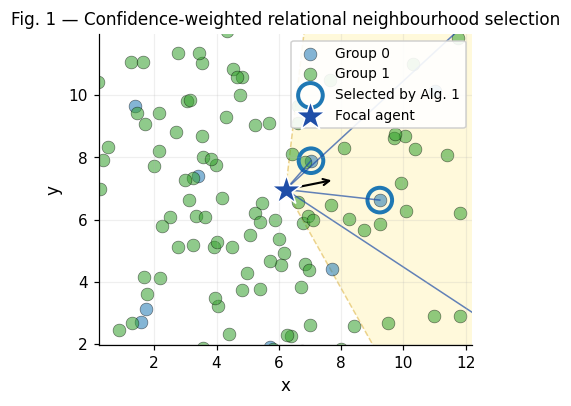

Selected 4 neighbours; aggregate S = 3.999 ≥ C=3.0


In [11]:
# ===== Figure 1: schematic =====
np.random.seed(11)
sim = FlockSim(N=240, model='mindflock', eta=0.0, C=3.0, seed=11)
# Pick a focal agent in group 0 near the centre
gmask = (sim.groups == 0)
focal_candidates = np.where(gmask)[0]
center = np.mean(sim.positions, axis=0)
dists  = np.linalg.norm(sim.positions[focal_candidates] - center, axis=1)
i_focal = focal_candidates[np.argmin(dists)]

# Force the focal agent to face roughly to the right for clarity
sim.velocities[i_focal] = np.array([1.0, 0.2])
sim.velocities[i_focal] /= np.linalg.norm(sim.velocities[i_focal])

# Run the actual neighbourhood selection by performing one step internally
# but keeping the result for visualisation
nx, ny = sim._noise_vectors()
new_v, new_p, nbr = step_mindflock(
    sim.positions, sim.velocities, sim.S_matrix, sim.shells,
    sim.C, 0.5 * sim.alpha, sim.kappa, 0.0, 0.0, nx*0, ny*0, sim.lambdas)

# Recover *which* neighbours were accepted by re-running Algorithm 1 in numpy
def relational_neighbourhood_numpy(i, sim):
    pos = sim.positions
    vel = sim.velocities
    S   = sim.S_matrix
    h   = vel[i] / max(np.linalg.norm(vel[i]), 1e-12)
    rmax = sim.shells[-1]
    cos_h = np.cos(0.5 * sim.alpha)
    rel = pos - pos[i]
    d   = np.linalg.norm(rel, axis=1)
    dot = rel @ h
    mask = (d > 1e-12) & (d <= rmax) & (dot > 0) & (dot >= cos_h * d)
    mask[i] = False
    cand = np.where(mask)[0]
    cand_d = d[cand]
    cand_S = S[i, cand]
    k_min = int(np.ceil(sim.C))
    for rs in sim.shells:
        in_rs = cand_d <= rs
        if in_rs.sum() < k_min:
            continue
        sub = cand[in_rs]
        sub_S = cand_S[in_rs]
        order = np.argsort(-sub_S)
        cum = np.cumsum(sub_S[order])
        for k in range(len(cum)):
            if (k + 1) >= k_min and cum[k] >= sim.C:
                return sub[order][:k+1]
    if len(cand) == 0:
        return np.array([], dtype=int)
    order = np.argsort(-cand_S)
    return cand[order][:min(len(cand), k_min)]

selected = relational_neighbourhood_numpy(i_focal, sim)

fig, ax = plt.subplots(figsize=(4, 5))
# Draw vision cone wedge
from matplotlib.patches import Wedge, Circle
fp = sim.positions[i_focal]
fh = sim.velocities[i_focal] / np.linalg.norm(sim.velocities[i_focal])
ang0 = np.degrees(np.arctan2(fh[1], fh[0])) - np.degrees(0.5 * sim.alpha)
ang1 = np.degrees(np.arctan2(fh[1], fh[0])) + np.degrees(0.5 * sim.alpha)
wedge = Wedge(fp, sim.shells[-1] * 0.55, ang0, ang1,
              facecolor='#fff3b0', edgecolor='#d4a017', alpha=0.45,
              linestyle='--', lw=1.0)
ax.add_patch(wedge)
# All other agents
for g in range(N_GROUPS):
    m = (sim.groups == g)
    ax.scatter(sim.positions[m, 0], sim.positions[m, 1],
               s=70, c=GROUP_COLORS[g], alpha=0.55,
               edgecolors='k', linewidths=0.4,
               label=f'Group {g}')
# Selected neighbours: draw bold ring
ax.scatter(sim.positions[selected, 0], sim.positions[selected, 1],
           s=260, facecolors='none', edgecolors=GROUP_COLORS[0],
           linewidths=2.6, label='Selected by Alg. 1')
# Lines from focal to selected
for j in selected:
    ax.plot([fp[0], sim.positions[j, 0]], [fp[1], sim.positions[j, 1]],
            color='#1f4ea8', lw=1.0, alpha=0.7, zorder=1)
# Focal star
ax.scatter([fp[0]], [fp[1]], marker='*', s=420,
           c='#1f4ea8', edgecolors='white', linewidths=1.0,
           label='Focal agent', zorder=5)
# Heading arrow
ax.annotate('', xy=fp + 1.6 * fh, xytext=fp,
            arrowprops=dict(arrowstyle='->', color='black', lw=1.4))
ax.set_aspect('equal')
ax.grid(alpha=0.2)
ax.legend(loc='upper right', framealpha=0.9, ncol=1, fontsize=9)
ax.set_title('Fig. 1 — Confidence-weighted relational neighbourhood selection')
ax.set_xlabel('x'); ax.set_ylabel('y')
# Crop to vicinity of focal
ax.set_xlim(fp[0] - 6, fp[0] + 6)
ax.set_ylim(fp[1] - 5, fp[1] + 5)
plt.savefig(os.path.join(OUT_DIR, "fig1_schematic.png"))
plt.show()
print(f"Selected {len(selected)} neighbours; aggregate S = {sim.S_matrix[i_focal, selected].sum():.3f} ≥ C={sim.C}")


## Figure 2 — Order parameters vs confidence threshold $C$

MIND-FLOCK only. Steady-state global $\Phi_\infty$ and per-group $\Phi_{g,\infty}$
are time-averaged over the second half of each run; error bars are $\pm$ 1 s.d.
across seeds.

Edit `N`, `T`, `N_SEEDS`, `C_VALUES`, `ETA_VALUES` at the top of the cell.

  η=0.20 done (15.0s elapsed)
  η=0.50 done (30.7s elapsed)
  η=0.80 done (45.8s elapsed)
Total: 45.8s


/var/folders/2k/pt553bzn4gg2sgfbpzfk2mym0000gn/T/ipykernel_21323/1836723076.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mplcm.get_cmap('viridis', len(ETA_VALUES) + 1)


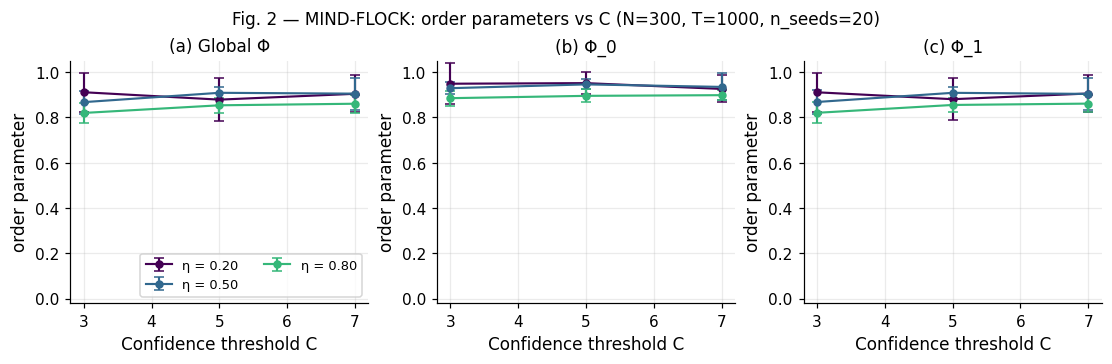

In [16]:
N        = 300
T        = 1000
N_SEEDS  = 20
C_VALUES = np.array([3., 5., 7.])
ETA_VALUES = [0.20, 0.50, 0.80]

t0 = time.time()
results = {}                                      # results[eta][C] = dict
for eta in ETA_VALUES:
    results[eta] = {}
    for C in C_VALUES:
        ens = run_ensemble('mindflock', N=N, T=T, n_seeds=N_SEEDS,
                           C=float(C), eta=float(eta), gamma=0.0)
        Phi_inf  = time_avg_tail(ens['Phi'],   frac=0.5)              # (seed,)
        Phi_g_inf = time_avg_tail(ens['Phi_g'], frac=0.5)             # (seed, g)
        results[eta][float(C)] = dict(
            Phi_mean    = Phi_inf.mean(),
            Phi_std     = Phi_inf.std(),
            Phi_g_mean  = Phi_g_inf.mean(axis=0),
            Phi_g_std   = Phi_g_inf.std(axis=0),
        )
    print(f"  η={eta:.2f} done ({time.time()-t0:.1f}s elapsed)")
print(f"Total: {time.time()-t0:.1f}s")

# --- plot 2x2 panel ---
fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), sharex=True)
panels = [('global', None), ('Φ_g', 0), ('Φ_g', 1)] # Corrected: Removed ('Φ_g', 2)
labels = ['(a) Global Φ', '(b) Φ_0', '(c) Φ_1', ''] # Corrected: Adjusted labels to match panels
cmap = mplcm.get_cmap('viridis', len(ETA_VALUES) + 1)
for ax, (kind, g), lab in zip(axes.ravel(), panels, labels):
    for k, eta in enumerate(ETA_VALUES):
        x = C_VALUES
        if kind == 'global':
            y  = np.array([results[eta][float(C)]['Phi_mean'] for C in C_VALUES])
            ye = np.array([results[eta][float(C)]['Phi_std']  for C in C_VALUES])
        else:
            y  = np.array([results[eta][float(C)]['Phi_g_mean'][g] for C in C_VALUES])
            ye = np.array([results[eta][float(C)]['Phi_g_std'][g]  for C in C_VALUES])
        ax.errorbar(x, y, yerr=ye, marker='o', ms=4.5, capsize=3,
                    color=cmap(k), label=f'η = {eta:.2f}', lw=1.4)
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(lab)
    ax.set_xlabel('Confidence threshold C')
    ax.set_ylabel('order parameter')
    if lab == '(a) Global Φ':
        ax.legend(ncol=2, fontsize=8.5, loc='lower right')
# Hide the fourth subplot if it's unused
if len(panels) < len(axes.ravel()):
    for i in range(len(panels), len(axes.ravel())):
        axes.ravel()[i].set_visible(False)
fig.suptitle(f'Fig. 2 — MIND-FLOCK: order parameters vs C (N={N}, T={T}, n_seeds={N_SEEDS})',
             fontsize=11)
plt.savefig(os.path.join(OUT_DIR, "fig2_order_vs_C.png"))
plt.show()

# Save numeric data
np.savez(os.path.join(OUT_DIR, "fig2_data.npz"),
         C=C_VALUES, eta=np.array(ETA_VALUES),
         Phi_mean=np.array([[results[e][float(C)]['Phi_mean']
                             for C in C_VALUES] for e in ETA_VALUES]),
         Phi_g_mean=np.array([[results[e][float(C)]['Phi_g_mean']
                               for C in C_VALUES] for e in ETA_VALUES]))

## Figure 3 — Order parameters vs noise $\eta$, multiple $C$

Same observables as Fig. 2 but on an $\eta$ scan, holding $C$ fixed. Per-group orders sit systematically above global $\Phi$ across the entire scanned domain — the empirical signature of intra-sub-group consensus (Theorem 1).

  C=3.0 done (41.4s)
  C=5.0 done (82.8s)
  C=7.0 done (123.7s)
Total: 123.7s


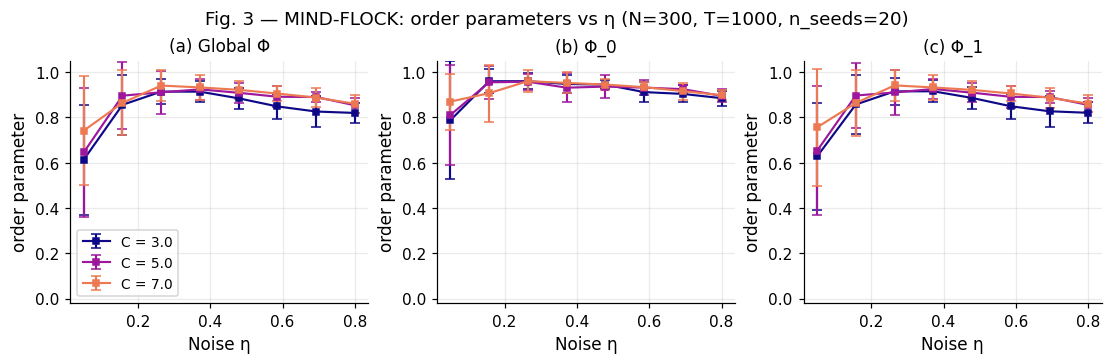

In [17]:
N        = 300
T        = 1000
N_SEEDS  = 20
ETA_VALUES = np.linspace(0.05, 0.80, 8)
C_VALUES = [3.0, 5.0, 7.0]

t0 = time.time()
results3 = {}
for C in C_VALUES:
    results3[C] = {}
    for eta in ETA_VALUES:
        ens = run_ensemble('mindflock', N=N, T=T, n_seeds=N_SEEDS,
                           C=float(C), eta=float(eta), gamma=0.0)
        Phi_inf   = time_avg_tail(ens['Phi'],   frac=0.5)
        Phi_g_inf = time_avg_tail(ens['Phi_g'], frac=0.5)
        results3[C][float(eta)] = dict(
            Phi_mean   = Phi_inf.mean(),
            Phi_std    = Phi_inf.std(),
            Phi_g_mean = Phi_g_inf.mean(axis=0),
            Phi_g_std  = Phi_g_inf.std(axis=0),
        )
    print(f"  C={C} done ({time.time()-t0:.1f}s)")
print(f"Total: {time.time()-t0:.1f}s")

fig, axes = plt.subplots(1, 3, figsize=(10, 3.2), sharex=True)
panels = [('global', None), ('Φ_g', 0), ('Φ_g', 1)]
labels = ['(a) Global Φ', '(b) Φ_0', '(c) Φ_1', '']
cmap = plt.get_cmap('plasma', len(C_VALUES) + 1)
for ax, (kind, g), lab in zip(axes.ravel(), panels, labels):
    for k, C in enumerate(C_VALUES):
        x = ETA_VALUES
        if kind == 'global':
            y  = np.array([results3[C][float(e)]['Phi_mean'] for e in ETA_VALUES])
            ye = np.array([results3[C][float(e)]['Phi_std']  for e in ETA_VALUES])
        else:
            y  = np.array([results3[C][float(e)]['Phi_g_mean'][g] for e in ETA_VALUES])
            ye = np.array([results3[C][float(e)]['Phi_g_std'][g]  for e in ETA_VALUES])
        ax.errorbar(x, y, yerr=ye, marker='s', ms=4.5, capsize=3,
                    color=cmap(k), label=f'C = {C}', lw=1.4)
    ax.set_ylim(-0.02, 1.05)
    ax.set_title(lab); ax.set_xlabel('Noise η'); ax.set_ylabel('order parameter')
    if lab == '(a) Global Φ':
        ax.legend(fontsize=9, loc='lower left')
# Hide the fourth subplot if it's unused
if len(panels) < len(axes.ravel()):
    for i in range(len(panels), len(axes.ravel())):
        axes.ravel()[i].set_visible(False)
fig.suptitle(f'Fig. 3 — MIND-FLOCK: order parameters vs η (N={N}, T={T}, n_seeds={N_SEEDS})')
plt.savefig(os.path.join(OUT_DIR, "fig3_order_vs_eta.png"))
plt.show()
np.savez(os.path.join(OUT_DIR, "fig3_data.npz"),
         eta=ETA_VALUES, C=np.array(C_VALUES),
         Phi_mean=np.array([[results3[C][float(e)]['Phi_mean']
                             for e in ETA_VALUES] for C in C_VALUES]))

## Figure 4 — MIND-FLOCK vs three matched controls (the central empirical result)

Three panels:

* **(a)** Steady-state $\Phi_\infty$ vs noise $\eta$ for the four models on identical seeds.
* **(b)** Per-group orders (markers) and global order (lines) for each model at $\eta=0.4$, illustrating the per-group-vs-global gap that survives only in identity-aware models.
* **(c)** Identity-conditional pair correlation $g_{gg'}(r)$ at the end of the run, averaged across seeds. MIND-FLOCK shows depressed inter-group $g(r)$ — the strongest signature of identity preservation.

  mindflock                 done (19.7s)
  similarity_vicsek         done (39.0s)
  topological_vicsek        done (60.8s)
  metric_vicsek             done (66.7s)
Total: 66.7s


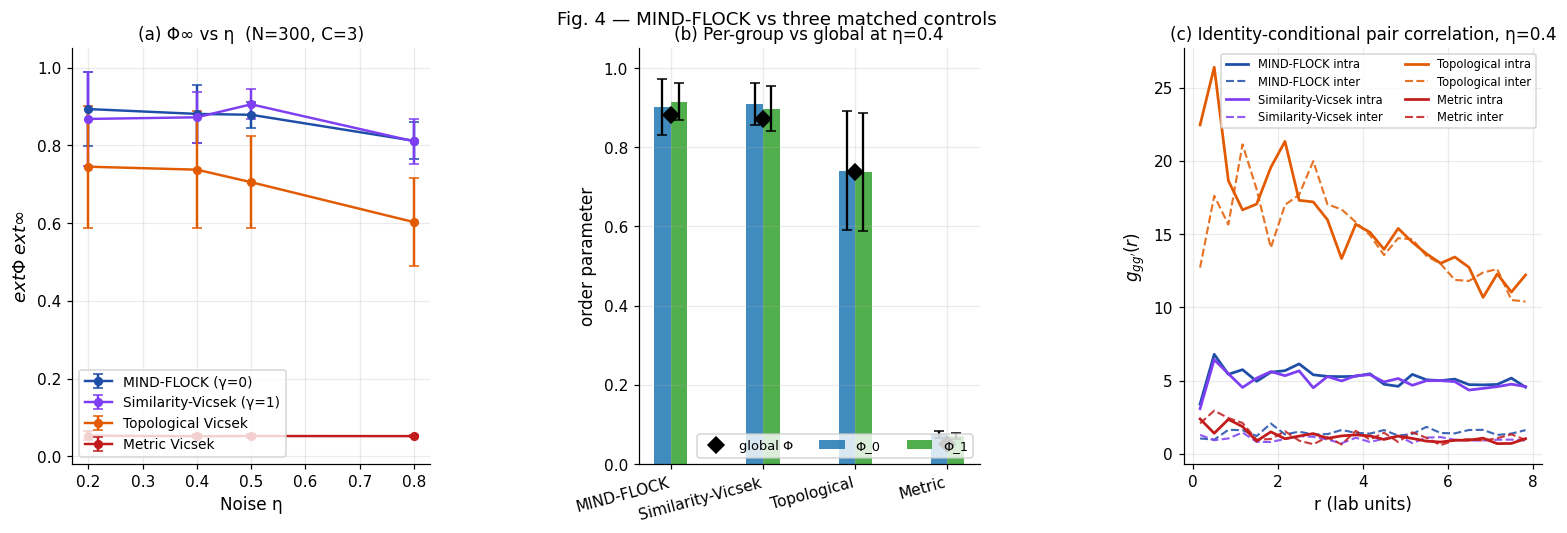


Order-parameter fluctuations σ_Φ over second half, η = 0.40:
  MIND-FLOCK (γ=0)                    σ_Φ = 0.1116   (seed std = 0.0766)
  Similarity-Vicsek (γ=1)             σ_Φ = 0.1226   (seed std = 0.0693)
  Topological Vicsek                  σ_Φ = 0.1654   (seed std = 0.0862)
  Metric Vicsek                       σ_Φ = 0.0262   (seed std = 0.0030)


In [17]:
# ===== Figure 4: 4-way comparison =====
N        = 300
T        = 1000
N_SEEDS  = 20
ETA_VALUES = np.array([0.20, 0.40, 0.50, 0.80])
C        = 3
ETA_PANEL_BC = 0.40                                         # for panels (b) and (c)

t0 = time.time()
results4 = {}
for model in FlockSim.MODELS:
    results4[model] = {}
    for eta in ETA_VALUES:
        store_traj = (abs(eta - ETA_PANEL_BC) < 1e-9)        # only need traj at one η
        ens = run_ensemble(model, N=N, T=T, n_seeds=N_SEEDS,
                           C=C, eta=float(eta), gamma=0.0,
                           store_traj=False)
        Phi_inf   = time_avg_tail(ens['Phi'],   frac=0.5)
        Phi_g_inf = time_avg_tail(ens['Phi_g'], frac=0.5)
        results4[model][float(eta)] = dict(
            Phi_mean   = Phi_inf.mean(),
            Phi_std    = Phi_inf.std(),
            Phi_g_mean = Phi_g_inf.mean(axis=0),
            Phi_g_std  = Phi_g_inf.std(axis=0),
            finals     = ens['finals'] if abs(eta - ETA_PANEL_BC) < 1e-9 else None,
        )
    print(f"  {model:25s} done ({time.time()-t0:.1f}s)")
print(f"Total: {time.time()-t0:.1f}s")

# --- plotting ---
fig = plt.figure(figsize=(14, 4.6))
gs  = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.0, 1.05], wspace=0.28)
ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1])
ax_c = fig.add_subplot(gs[0, 2])

# Panel (a): Phi_inf vs eta, four models
for model in FlockSim.MODELS:
    y  = np.array([results4[model][float(e)]['Phi_mean'] for e in ETA_VALUES])
    ye = np.array([results4[model][float(e)]['Phi_std']  for e in ETA_VALUES])
    ax_a.errorbar(ETA_VALUES, y, yerr=ye, marker='o', ms=5, capsize=3, lw=1.6,
                  color=MODEL_COLORS[model], label=MODEL_LABELS[model])
ax_a.set_xlabel('Noise η'); ax_a.set_ylabel(r'$    ext{Φ}_    ext{∞}$', fontsize='large')
ax_a.set_title(f'(a) Φ∞ vs η  (N={N}, C={C})')
ax_a.set_ylim(-0.02, 1.05)
ax_a.legend(fontsize=9, loc='lower left')

# Panel (b): Per-group vs global at the chosen eta, all models
xs = np.arange(len(FlockSim.MODELS))
width = 0.18
for k, g in enumerate(range(N_GROUPS)):
    vals = [results4[m][ETA_PANEL_BC]['Phi_g_mean'][g] for m in FlockSim.MODELS]
    errs = [results4[m][ETA_PANEL_BC]['Phi_g_std'][g]  for m in FlockSim.MODELS]
    ax_b.bar(xs + (k - (N_GROUPS - 1) / 2) * width, vals, width=width, yerr=errs, capsize=3,
             color=GROUP_COLORS[g], alpha=0.85, label=f'Φ_{g}')
glob_vals = [results4[m][ETA_PANEL_BC]['Phi_mean'] for m in FlockSim.MODELS]
ax_b.plot(xs, glob_vals, marker='D', ms=7, lw=0, color='black', label='global Φ')
ax_b.set_xticks(xs)
ax_b.set_xticklabels([MODEL_LABELS[m].split(' ')[0] for m in FlockSim.MODELS],
                     rotation=15, ha='right')
ax_b.set_ylim(0, 1.05)
ax_b.set_title(f'(b) Per-group vs global at η={ETA_PANEL_BC}')
ax_b.set_ylabel('order parameter')
ax_b.legend(ncol=4, fontsize=8.5, loc='lower right')

# Panel (c): identity-conditional pair correlation, averaged over seeds
r_max = 8.0
n_bins = 24
gr_intra = {m: [] for m in FlockSim.MODELS}
gr_inter = {m: [] for m in FlockSim.MODELS}
for model in FlockSim.MODELS:
    finals = results4[model][ETA_PANEL_BC]['finals']
    if finals is None:
        continue
    for fnl in finals:
        # Pool all intra-group pairs vs all inter-group pairs
        intra_pieces = []
        inter_pieces = []
        for g1 in range(N_GROUPS):
            for g2 in range(N_GROUPS):
                cen, gr = pair_correlation(fnl['positions'], fnl['groups'],
                                           g1, g2, r_max=r_max, n_bins=n_bins)
                if g1 == g2:
                    intra_pieces.append(gr)
                elif g1 < g2:
                    inter_pieces.append(gr)
        gr_intra[model].append(np.mean(np.stack(intra_pieces, axis=0), axis=0))
        gr_inter[model].append(np.mean(np.stack(inter_pieces, axis=0), axis=0))
    gr_intra[model] = np.mean(np.stack(gr_intra[model], axis=0), axis=0)
    gr_inter[model] = np.mean(np.stack(gr_inter[model], axis=0), axis=0)

# Centres for the bins
bins = np.linspace(0.0, r_max, n_bins + 1); centres = 0.5 * (bins[1:] + bins[:-1])
for model in FlockSim.MODELS:
    if isinstance(gr_intra[model], list):
        continue
    ax_c.plot(centres, gr_intra[model], color=MODEL_COLORS[model], lw=1.8,
              label=f"{MODEL_LABELS[model].split(' ')[0]} intra")
    ax_c.plot(centres, gr_inter[model], color=MODEL_COLORS[model], lw=1.4,
              ls='--', alpha=0.85,
              label=f"{MODEL_LABELS[model].split(' ')[0]} inter")
ax_c.set_xlabel('r (lab units)')
ax_c.set_ylabel(r'$g_{gg^{\prime}}(r)$')
ax_c.set_title(f'(c) Identity-conditional pair correlation, η={ETA_PANEL_BC}')
ax_c.legend(fontsize=7.5, ncol=2, loc='upper right')

fig.suptitle('Fig. 4 — MIND-FLOCK vs three matched controls', y=1.02)
plt.savefig(os.path.join(OUT_DIR, "fig4_four_way.png"), bbox_inches='tight')
plt.show()

# Order-parameter fluctuations (Table 1 data)
print("\nOrder-parameter fluctuations σ_Φ over second half, η = 0.40:")
for m in FlockSim.MODELS:
    ens = run_ensemble(m, N=N, T=T, n_seeds=N_SEEDS, C=C, eta=ETA_PANEL_BC, gamma=0.0)
    sig_mean, sig_per_seed = fluctuations_phi(ens['Phi'])
    print(f"  {MODEL_LABELS[m]:35s} σ_Φ = {sig_mean:.4f}   (seed std = {sig_per_seed.std():.4f})")

## Figure 5 — Finite-size scaling

$\Phi_\infty(N)$ at fixed density $\rho = N/L^2 = 2.4$ for $N \in \{60, 120, 240, 480\}$,
all four models, on matched seeds. The MIND-FLOCK / Vicsek gap should persist across the scanned range, supporting the claim that the advantage is not a finite-size artefact.

  N=100 done (8.3s)
  N=200 done (25.2s)
  N=300 done (52.2s)
  N=500 done (114.1s)
Total: 114.1s


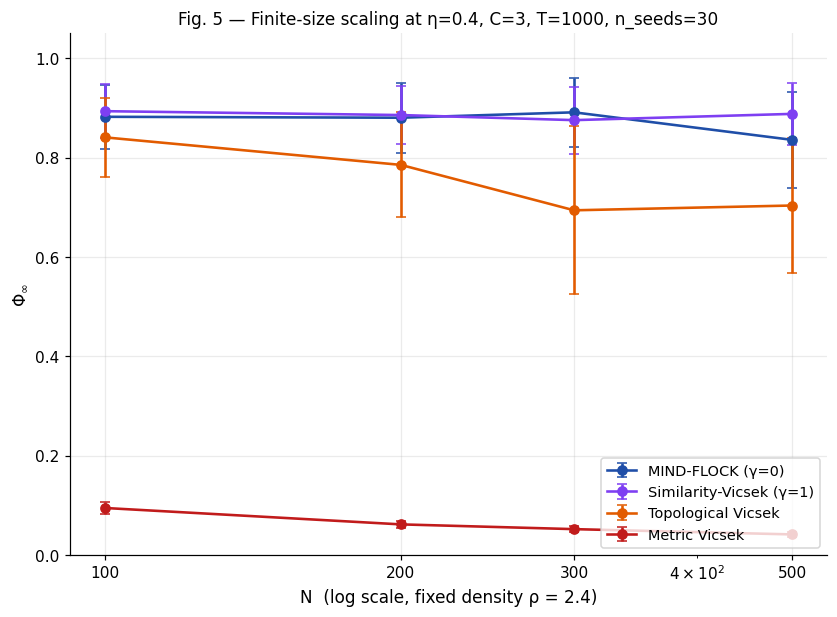

In [21]:
# ===== Figure 5: finite-size scaling =====
N_VALUES = [100, 200, 300, 500]
T        = 1000
N_SEEDS  = 30
C        = 3
ETA      = 0.4

t0 = time.time()
results5 = {m: {N: None for N in N_VALUES} for m in FlockSim.MODELS}
for N in N_VALUES:
    for model in FlockSim.MODELS:
        ens = run_ensemble(model, N=N, T=T, n_seeds=N_SEEDS,
                           C=C, eta=ETA, gamma=0.0)
        Phi_inf = time_avg_tail(ens['Phi'], frac=0.5)
        results5[model][N] = dict(mean=Phi_inf.mean(), std=Phi_inf.std())
    print(f"  N={N} done ({time.time()-t0:.1f}s)")
print(f"Total: {time.time()-t0:.1f}s")

fig, ax = plt.subplots(figsize=(7.5, 5.5))
for model in FlockSim.MODELS:
    y  = np.array([results5[model][N]['mean'] for N in N_VALUES])
    ye = np.array([results5[model][N]['std']  for N in N_VALUES])
    ax.errorbar(N_VALUES, y, yerr=ye, marker='o', ms=6, capsize=3, lw=1.7,
                color=MODEL_COLORS[model], label=MODEL_LABELS[model])
ax.set_xscale('log')
ax.set_xticks(N_VALUES); ax.set_xticklabels([str(N) for N in N_VALUES])
ax.set_xlabel('N  (log scale, fixed density ρ = 2.4)')
ax.set_ylabel(r'$\Phi_\infty$')
ax.set_ylim(0, 1.05)
ax.set_title(f'Fig. 5 — Finite-size scaling at η={ETA}, C={C}, T={T}, n_seeds={N_SEEDS}')
ax.legend(fontsize=9.5, loc='lower right')
plt.savefig(os.path.join(OUT_DIR, "fig5_finite_size.png"))
plt.show()

# Save data
arr = np.zeros((len(FlockSim.MODELS), len(N_VALUES), 2))
for i, m in enumerate(FlockSim.MODELS):
    for j, N in enumerate(N_VALUES):
        arr[i, j, 0] = results5[m][N]['mean']
        arr[i, j, 1] = results5[m][N]['std']
np.savez(os.path.join(OUT_DIR, "fig5_data.npz"),
         N=np.array(N_VALUES), models=list(FlockSim.MODELS), values=arr)


## Figure 6 — Long-time persistence and ballistic centroid divergence

Two panels:

* **(a)** Per-group order $\Phi_g(t)$ for MIND-FLOCK over $T=1000$. Per Corollary 2, per-group orders should saturate after a transient and remain stable.
* **(b)** Inter-group centroid pairwise separations $\|\bar x_g - \bar x_{g'}\|$ in the lab frame. By Corollary 3, in open boundaries these grow approximately linearly once the inter-group angles $\theta_{gg'}$ saturate.

Done (5.2s)


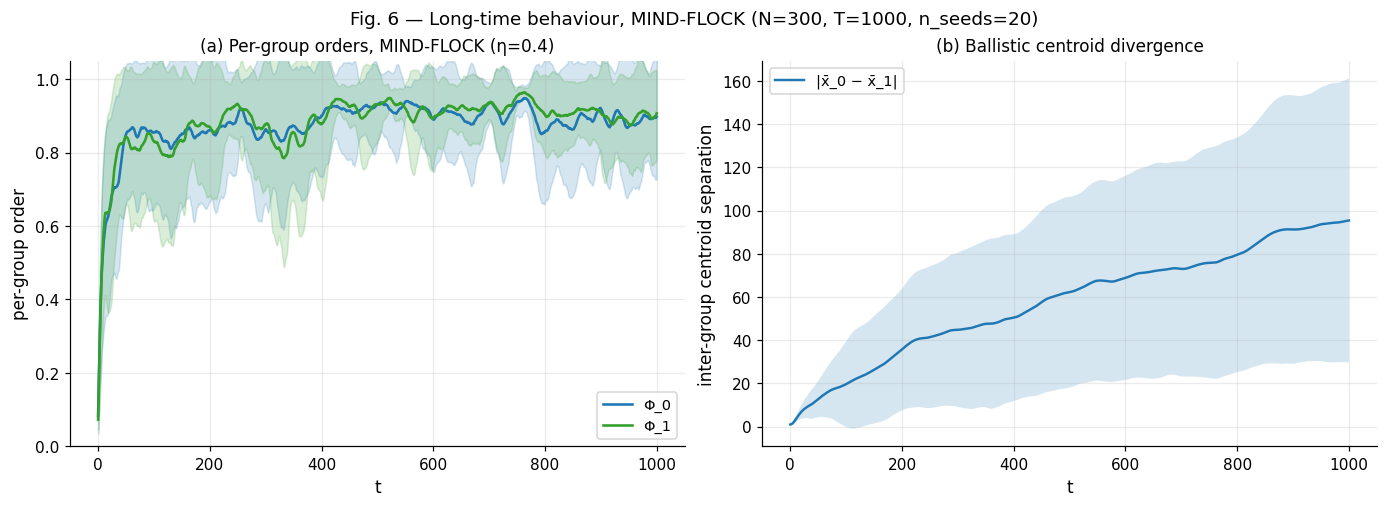

In [23]:
# ===== Figure 6: long-time persistence + centroid divergence =====
N       = 300
T       = 1000
N_SEEDS = 20
C       = 3
ETA     = 0.40

t0 = time.time()
ens = run_ensemble('mindflock', N=N, T=T, n_seeds=N_SEEDS,
                   C=C, eta=ETA, gamma=0.0)
print(f"Done ({time.time()-t0:.1f}s)")

t_axis = np.arange(T + 1)
Phi_g_mean = ens['Phi_g'].mean(axis=0)               # (g, t)
Phi_g_std  = ens['Phi_g'].std(axis=0)
cm = ens['cm']                                       # (seed, g, 2, t)


# Pairwise centroid separations averaged over seeds
separations = []
for g1 in range(N_GROUPS):
    for g2 in range(g1 + 1, N_GROUPS):
        sep = np.linalg.norm(cm[:, g1, :, :] - cm[:, g2, :, :], axis=1)
        separations.append((sep, f'|x̄_{g1} − x̄_{g2}|'))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.5))

ax = axes[0]
for g in range(N_GROUPS):
    ax.plot(t_axis, Phi_g_mean[g], color=GROUP_COLORS[g], lw=1.7, label=f'Φ_{g}')
    ax.fill_between(t_axis, Phi_g_mean[g] - Phi_g_std[g], Phi_g_mean[g] + Phi_g_std[g],
                    color=GROUP_COLORS[g], alpha=0.18)
ax.set_xlabel('t'); ax.set_ylabel('per-group order')
ax.set_ylim(0, 1.05)
ax.set_title(f'(a) Per-group orders, MIND-FLOCK (η={ETA})')
ax.legend(loc='lower right', fontsize=9.5)

ax = axes[1]
for arr, lab in separations:
    m = arr.mean(axis=0); s = arr.std(axis=0)
    ax.plot(t_axis, m, lw=1.6, label=lab)
    ax.fill_between(t_axis, m - s, m + s, alpha=0.18)
ax.set_xlabel('t'); ax.set_ylabel('inter-group centroid separation')
ax.set_title('(b) Ballistic centroid divergence')
ax.legend(loc='upper left', fontsize=9.5)

fig.suptitle(f'Fig. 6 — Long-time behaviour, MIND-FLOCK (N={N}, T={T}, n_seeds={N_SEEDS})')
plt.savefig(os.path.join(OUT_DIR, "fig6_long_time.png"))
plt.show()
np.savez(os.path.join(OUT_DIR, "fig6_data.npz"),
         t=t_axis, Phi_g_mean=Phi_g_mean, Phi_g_std=Phi_g_std,
         separations_mean=[s[0].mean(0) for s in separations])


## Figure 7 — Phase diagrams in the $(\eta, C)$ plane (4 models)

Heatmaps of $\Phi_\infty(\eta, C)$. The metric and topological Vicsek panels should be approximately $C$-independent (those rules don't read $C$); the similarity-Vicsek panel inherits partial $C$-dependence through the relational neighbourhood selection step; MIND-FLOCK has the largest ordered region and the strongest noise-resilience at large $C$.

> **Heads-up.** This is the heaviest cell in the notebook. Default grid is $|η|=4 \times |C|=7 = 28$ points × 4 models × `N_SEEDS` realisations × $T$ steps. With `N=120`, `T=300`, `N_SEEDS=20` it runs in ≈ 25–35 minutes on Colab CPU. To shorten, reduce any of `N_SEEDS`, `T`, `C_GRID`, `ETA_GRID`.

  progress 8/48 (34s elapsed)
  progress 16/48 (70s elapsed)
  progress 24/48 (107s elapsed)
  progress 32/48 (148s elapsed)
  progress 40/48 (190s elapsed)
  progress 48/48 (236s elapsed)
Total: 236.5s


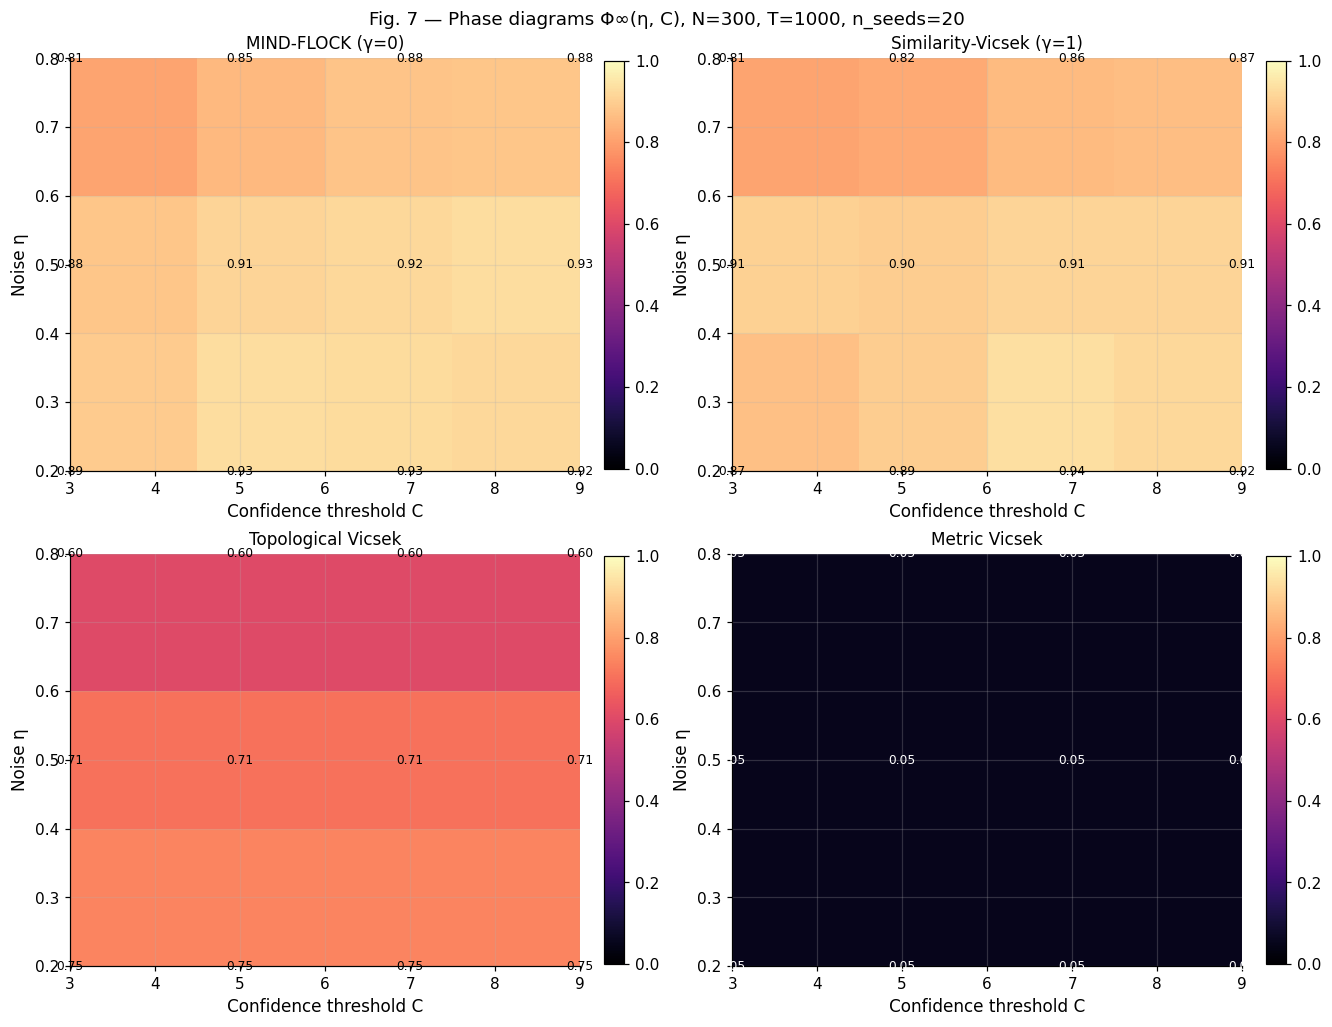

In [24]:
# ===== Figure 7: phase diagrams =====
N         = 300
T         = 1000
N_SEEDS   = 20
C_GRID    = np.array([3., 5., 7., 9.,])         # 7 values per request
ETA_GRID  = np.array([0.20, 0.50, 0.80])              # 4 values

t0 = time.time()
phase = {m: np.zeros((len(ETA_GRID), len(C_GRID))) for m in FlockSim.MODELS}
phase_std = {m: np.zeros_like(phase['mindflock']) for m in FlockSim.MODELS}
total_pts = len(ETA_GRID) * len(C_GRID) * len(FlockSim.MODELS)
done = 0
for ie, eta in enumerate(ETA_GRID):
    for iC, C in enumerate(C_GRID):
        for model in FlockSim.MODELS:
            ens = run_ensemble(model, N=N, T=T, n_seeds=N_SEEDS,
                               C=float(C), eta=float(eta), gamma=0.0)
            Phi_inf = time_avg_tail(ens['Phi'], frac=0.5)
            phase[model][ie, iC]     = Phi_inf.mean()
            phase_std[model][ie, iC] = Phi_inf.std()
            done += 1
            if done % 8 == 0:
                print(f"  progress {done}/{total_pts} "
                      f"({time.time()-t0:.0f}s elapsed)")
print(f"Total: {time.time()-t0:.1f}s")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, model in zip(axes.ravel(),
                     ('mindflock', 'similarity_vicsek',
                      'topological_vicsek', 'metric_vicsek')):
    img = phase[model]
    im = ax.imshow(img, origin='lower', aspect='auto',
                   extent=[C_GRID[0], C_GRID[-1], ETA_GRID[0], ETA_GRID[-1]],
                   cmap='magma', vmin=0, vmax=1.0)
    ax.set_xlabel('Confidence threshold C')
    ax.set_ylabel('Noise η')
    ax.set_title(MODEL_LABELS[model])
    # Annotate cells with values
    for ie in range(len(ETA_GRID)):
        for iC in range(len(C_GRID)):
            ax.text(C_GRID[iC], ETA_GRID[ie], f"{img[ie,iC]:.2f}",
                    ha='center', va='center',
                    color='white' if img[ie, iC] < 0.55 else 'black',
                    fontsize=8)
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
fig.suptitle(f'Fig. 7 — Phase diagrams Φ∞(η, C), N={N}, T={T}, n_seeds={N_SEEDS}',
             y=1.02)
plt.savefig(os.path.join(OUT_DIR, "fig7_phase_diagrams.png"), bbox_inches='tight')
plt.show()

np.savez(os.path.join(OUT_DIR, "fig7_data.npz"),
         eta=ETA_GRID, C=C_GRID,
         **{f"{m}_mean": phase[m]    for m in FlockSim.MODELS},
         **{f"{m}_std":  phase_std[m] for m in FlockSim.MODELS})


---
## Appendix — MIND-FLOCK vs Similarity-Vicsek: head-to-head comparisons

These comparisons use the **variable-velocity (Cucker-Smale style) dynamics** from
the dedicated two-group notebook, ported into this notebook's infrastructure.

### Key dynamics difference vs the main figures

| Property | Main figures (Figs 1–8) | This Appendix |
|---|---|---|
| Velocity update | `v_new = normalise(v_old + κ·align + η·ξ)` | `v_new = v_old + κ·Σw_ij·v_j + η·ξ` |
| Speed | Fixed unit speed | Clamped to `[1−v, 1+v]`, carries magnitude |
| W normalisation | Divided by `n_nbr` | **Not** normalised — raw weighted sum |
| Initial speeds | 1.0 exactly | `U[1−v_spread, 1+v_spread]` |
| Affinity kernel | Power-Cauchy p=2 | Power-Cauchy p=2 (same) |

The variable-velocity model is the one in which the compactness comparisons (R_gyr,
R_enc, R_max) are meaningful: speed differences create a Cucker-Smale-like speed
equilibration that is distinct from pure directional alignment.

**Both models share** the same initial state, same relational neighbourhood
(Algorithm 1), same noise stream, and same `v_spread` parameter.
The only difference is `w_ij_eff = (1−γ)·W_ij + γ·S_ij`.

**Parameters:** `N=330` (large=300, small=30, 10:1), `η=0.20`, `C=3.0`,
`T=1000`, 20 seeds, `v_spread=0.02`, Power-Cauchy `p=2`, `Δ=0.01`.


In [13]:
# ===== Variable-velocity step kernel for Appendix comparisons =====
# Implements the additive social-force dynamics from the two-group notebook (v4):
#   v_new = v_old + κ · Σ_j w_ij_eff · v_j  +  η · ξ_i
#   |v_new| clamped to [1 - v_spread, 1 + v_spread]
# W_ij is NOT divided by n_nbr (raw weighted sum acts as social force).
# Φ is computed from unit-normalised directions so it stays in [0,1].

@njit(cache=True, parallel=True, fastmath=True)
def step_varvel(positions, velocities, S_matrix, shells, C,
                half_alpha, kappa, eta, gamma,
                noise_x, noise_y, v_spread):
    """Variable-velocity γ-mixed step.
    gamma=0 → MIND-FLOCK   (many-body W_ij, un-normalised)
    gamma=1 → Similarity-Vicsek (plain S_ij, un-normalised)
    """
    N = positions.shape[0]
    cos_half_alpha = np.cos(half_alpha)
    n_shells = shells.shape[0]
    rmax     = shells[n_shells - 1]
    k_min    = int(np.ceil(C))
    v_lo     = 1.0 - v_spread
    v_hi     = 1.0 + v_spread

    new_vel   = np.empty_like(velocities)
    nbr_sizes = np.zeros(N, dtype=np.int64)

    for i in prange(N):
        vix = velocities[i, 0]; viy = velocities[i, 1]
        v_norm = np.sqrt(vix * vix + viy * viy)
        if v_norm < 1e-12:
            hx = 1.0; hy = 0.0
        else:
            hx = vix / v_norm; hy = viy / v_norm

        # ---- vision-cone candidates within rmax ----
        cand_j    = np.empty(N, dtype=np.int64)
        cand_dist = np.empty(N, dtype=np.float64)
        cand_S    = np.empty(N, dtype=np.float64)
        n_cand = 0
        for j in range(N):
            if j == i:
                continue
            dx = positions[j, 0] - positions[i, 0]
            dy = positions[j, 1] - positions[i, 1]
            d  = np.sqrt(dx * dx + dy * dy)
            if d < 1e-12 or d > rmax:
                continue
            dot = dx * hx + dy * hy
            if dot <= 0.0:
                continue
            if dot < cos_half_alpha * d:
                continue
            cand_j[n_cand]    = j
            cand_dist[n_cand] = d
            cand_S[n_cand]    = S_matrix[i, j]
            n_cand += 1

        # ---- Algorithm 1: cumulative shell expansion ----
        nbr_idx = np.empty(N, dtype=np.int64)
        n_nbr = 0
        found = False
        for s_idx in range(n_shells):
            rs = shells[s_idx]
            sub_pos = np.empty(n_cand, dtype=np.int64)
            n_sub = 0
            for k in range(n_cand):
                if cand_dist[k] <= rs:
                    sub_pos[n_sub] = k
                    n_sub += 1
            if n_sub < k_min:
                continue
            sub_S = np.empty(n_sub, dtype=np.float64)
            for k in range(n_sub):
                sub_S[k] = cand_S[sub_pos[k]]
            order = np.argsort(-sub_S)
            cumsum = 0.0
            k_use = -1
            for k in range(n_sub):
                cumsum += sub_S[order[k]]
                if (k + 1) >= k_min and cumsum >= C:
                    k_use = k + 1
                    break
            if k_use > 0:
                for k in range(k_use):
                    nbr_idx[k] = cand_j[sub_pos[order[k]]]
                n_nbr = k_use
                found = True
                break

        if (not found) and n_cand > 0:
            sub_S = np.empty(n_cand, dtype=np.float64)
            for k in range(n_cand):
                sub_S[k] = cand_S[k]
            order = np.argsort(-sub_S)
            n_nbr = n_cand if n_cand < k_min else k_min
            for k in range(n_nbr):
                nbr_idx[k] = cand_j[order[k]]

        nbr_sizes[i] = n_nbr

        # ---- γ-mixed social force: raw weighted sum (NOT divided by n_nbr) ----
        Ox = 0.0; Oy = 0.0
        if n_nbr > 0:
            # log-space W computation for numerical safety
            log_P = 0.0
            log_c = np.empty(n_nbr, dtype=np.float64)
            for k in range(n_nbr):
                S = S_matrix[i, nbr_idx[k]]
                if S < 0.0: S = 0.0
                if S > 1.0: S = 1.0
                cl = 1.0 + 2.0 * np.sqrt(S * (1.0 - S))
                log_c[k] = np.log(cl)
                log_P   += log_c[k]
            for k in range(n_nbr):
                j = nbr_idx[k]
                S = S_matrix[i, j]
                if S < 0.0: S = 0.0
                if S > 1.0: S = 1.0
                pref  = S + np.sqrt(S * (1.0 - S))
                W     = pref * np.exp(log_P - log_c[k])
                # γ-mix: gamma=0 → W_ij,  gamma=1 → S_ij
                w_eff = (1.0 - gamma) * W + gamma * S
                # accumulate raw weighted velocity (magnitudes count)
                Ox += w_eff * velocities[j, 0]
                Oy += w_eff * velocities[j, 1]
        # no fallback needed: if n_nbr==0, Ox=Oy=0 → v stays + noise only

        # ---- additive update: v_new = v_old + κ·social_force + η·ξ ----
        nx = vix + kappa * Ox + eta * noise_x[i]
        ny = viy + kappa * Oy + eta * noise_y[i]

        # ---- clamp |v_new| into [v_lo, v_hi] ----
        mag = np.sqrt(nx * nx + ny * ny)
        if mag > v_hi:
            nx *= v_hi / mag; ny *= v_hi / mag
        elif mag < v_lo:
            if mag > 1e-12:
                nx *= v_lo / mag; ny *= v_lo / mag
            else:
                nx = hx * v_lo; ny = hy * v_lo

        new_vel[i, 0] = nx
        new_vel[i, 1] = ny

    # ---- position update: x ← x + v (speed lives in |v|) ----
    new_pos = np.empty_like(positions)
    for i in range(N):
        new_pos[i, 0] = positions[i, 0] + new_vel[i, 0]
        new_pos[i, 1] = positions[i, 1] + new_vel[i, 1]

    return new_vel, new_pos, nbr_sizes

print("step_varvel compiled (variable-velocity Appendix kernel).")


step_varvel compiled (variable-velocity Appendix kernel).


In [14]:
# ===== VarVelFlockSim — variable-velocity simulator for Appendix =====
# Mirrors the old two-group notebook's FlockSim exactly, adapted to use
# this notebook's init_identities (70/30 split, Power-Cauchy p=2).

class VarVelFlockSim:
    """Two-model (MF vs SV) simulator with variable-velocity dynamics."""
    MODELS = ('mindflock', 'similarity_vicsek')

    def __init__(self, N=300, density=2.4, model='mindflock', seed=0,
                 C=3.0, shells=(50., 100., 150., 200., 400.),
                 alpha=0.8 * np.pi, kappa=0.9, eta=0.20,
                 v_spread=0.02, Delta_aff=0.01, p_aff=4.0):
        assert model in self.MODELS
        self.N        = int(N)
        self.density  = float(density)
        self.L        = float(np.sqrt(self.N / self.density))
        self.model    = model
        self.seed     = int(seed)
        self.C        = float(C)
        self.shells   = np.asarray(shells, dtype=np.float64)
        self.alpha    = float(alpha)
        self.kappa    = float(kappa)
        self.eta      = float(eta)
        self.gamma    = 0.0 if model == 'mindflock' else 1.0
        self.v_spread = float(v_spread)
        self._init_state(Delta_aff, p_aff)

    def _init_state(self, Delta_aff, p_aff):
        # Identity assignment (uses this notebook's 70/30 init_identities)
        self.identities, self.groups = init_identities(self.N, seed=self.seed)
        self.S_matrix = compute_affinity_matrix(
            self.identities, Delta=Delta_aff, p=p_aff)

        # Positions: Gaussian-centred
        rng = np.random.default_rng(self.seed + 7919)
        self.positions = rng.normal(self.L / 2, 0.5 * self.L,
                                    size=(self.N, 2)).astype(np.float64)
        # Velocities: random heading, magnitude ~ U[1-v_spread, 1+v_spread]
        angles = rng.uniform(0.0, 2.0 * np.pi, size=self.N)
        mags   = rng.uniform(1.0 - self.v_spread, 1.0 + self.v_spread,
                              size=self.N)
        self.velocities = (np.column_stack([np.cos(angles), np.sin(angles)])
                           * mags[:, None]).astype(np.float64)

        self._noise_rng = np.random.default_rng(self.seed + 271828)
        self._last_nbr  = np.zeros(self.N, dtype=np.int64)

    def _noise_vectors(self):
        u = self._noise_rng.uniform(0.0, 2.0 * np.pi, size=self.N)
        return np.cos(u), np.sin(u)

    def step(self):
        nx, ny = self._noise_vectors()
        new_v, new_p, nbr = step_varvel(
            self.positions, self.velocities, self.S_matrix, self.shells,
            self.C, 0.5 * self.alpha, self.kappa, self.eta, self.gamma,
            nx, ny, self.v_spread)
        self.velocities = new_v
        self.positions  = new_p
        self._last_nbr  = nbr

    def observe(self):
        v     = self.velocities
        norms = np.sqrt((v ** 2).sum(axis=1))
        # Φ from unit-normalised directions
        v_hat = v / np.maximum(norms[:, None], 1e-12)
        Mx = v_hat[:, 0].mean(); My = v_hat[:, 1].mean()
        Phi = float(np.sqrt(Mx * Mx + My * My))

        Phi_g    = np.zeros(N_GROUPS)
        cm       = np.zeros((N_GROUPS, 2))
        mean_spd = np.zeros(N_GROUPS)
        R_gyr    = np.zeros(N_GROUPS)
        R_max_g  = np.zeros(N_GROUPS)

        for g in range(N_GROUPS):
            m = (self.groups == g)
            if not m.any():
                continue
            vug = v_hat[m]
            pg  = self.positions[m]
            gMx = vug[:, 0].mean(); gMy = vug[:, 1].mean()
            Phi_g[g]    = float(np.sqrt(gMx * gMx + gMy * gMy))
            cm[g]       = pg.mean(axis=0)
            mean_spd[g] = float(norms[m].mean())
            dists       = np.linalg.norm(pg - cm[g], axis=1)
            R_gyr[g]    = float(np.sqrt((dists ** 2).mean()))
            R_max_g[g]  = float(dists.max())

        kbar = float(self._last_nbr.mean())
        return Phi, Phi_g, cm, mean_spd, R_gyr, R_max_g, kbar

    def run(self, T, store_every=1):
        n_store = (T // store_every) + 1
        Phi      = np.zeros(n_store)
        Phi_g    = np.zeros((N_GROUPS, n_store))
        cm       = np.zeros((N_GROUPS, 2, n_store))
        mean_spd = np.zeros((N_GROUPS, n_store))
        R_gyr    = np.zeros((N_GROUPS, n_store))
        R_max    = np.zeros((N_GROUPS, n_store))

        (Phi[0], Phi_g[:, 0], cm[:, :, 0],
         mean_spd[:, 0], R_gyr[:, 0], R_max[:, 0], _) = self.observe()
        idx = 0
        for t in range(1, T + 1):
            self.step()
            if t % store_every == 0:
                idx += 1
                (Phi[idx], Phi_g[:, idx], cm[:, :, idx],
                 mean_spd[:, idx], R_gyr[:, idx], R_max[:, idx], _) = self.observe()

        return dict(
            Phi=Phi, Phi_g=Phi_g, cm=cm,
            mean_spd=mean_spd, R_gyr=R_gyr, R_max=R_max,
            final_positions=self.positions.copy(),
            final_velocities=self.velocities.copy(),
            groups=self.groups.copy(),
        )


def run_varvel_ensemble(model, N=330, T=1000, n_seeds=20,
                        store_every=1, **sim_kwargs):
    """Ensemble runner for VarVelFlockSim.  Returns stacked arrays."""
    lists = {k: [] for k in ('Phi', 'Phi_g', 'cm', 'mean_spd', 'R_gyr', 'R_max')}
    finals = []
    for s in range(n_seeds):
        sim = VarVelFlockSim(N=N, model=model, seed=s, **sim_kwargs)
        out = sim.run(T=T, store_every=store_every)
        for k in lists:
            lists[k].append(out[k])
        finals.append(dict(positions=out['final_positions'],
                           velocities=out['final_velocities'],
                           groups=out['groups']))
    return {k: np.stack(lists[k], axis=0) for k in lists} | dict(
        finals=finals, model=model, N=N, T=T, n_seeds=n_seeds)


def tail_avg(arr, frac=0.4, axis=-1):
    T = arr.shape[axis]
    t0 = int((1.0 - frac) * T)
    return arr.take(indices=range(t0, T), axis=axis).mean(axis=axis)


print("VarVelFlockSim and run_varvel_ensemble defined.")
print(f"  v_spread default=0.02  → speeds in [0.98, 1.02], i.e. ≈2% magnitude spread")


VarVelFlockSim and run_varvel_ensemble defined.
  v_spread default=0.02  → speeds in [0.98, 1.02], i.e. ≈2% magnitude spread


In [15]:
# ===== Appendix: shared variable-velocity ensemble (MF vs SV) =====
_VV_N       = 300      # large=231, small=99 with 70/30 split
_VV_T       = 2000
_VV_SEEDS   = 30
_VV_C       = 5.0
_VV_ETA     = 0.40     # moderate noise; per two-group notebook recommendation
_VV_VSPREAD = 0.04     # small initial speed spread (Cucker-Smale regime)
_VV_MODELS  = ('mindflock', 'similarity_vicsek')

_APP_COLORS = {
    'mindflock'         : '#1f4ea8',
    'similarity_vicsek' : '#c11b1b',
}
_APP_LABELS = {
    'mindflock'         : 'MIND-FLOCK  (γ=0)',
    'similarity_vicsek' : 'Similarity-Vicsek  (γ=1)',
}

print(f"Config: N={_VV_N}, η={_VV_ETA}, C={_VV_C}, T={_VV_T}, "
      f"seeds={_VV_SEEDS}, v_spread={_VV_VSPREAD}")
print(f"Group split: large≈{int(_VV_N*0.9)}, small≈{int(_VV_N*0.1)} (90/10)")
_t0 = time.time()

vv_results = {}
for model in _VV_MODELS:
    ens = run_varvel_ensemble(model, N=_VV_N, T=_VV_T, n_seeds=_VV_SEEDS,
                              C=_VV_C, eta=_VV_ETA, v_spread=_VV_VSPREAD)
    Phi_inf   = tail_avg(ens['Phi'],   frac=0.4)        # (seed,)
    Phi_g_inf = tail_avg(ens['Phi_g'], frac=0.4)        # (seed, g)
    spd_inf   = tail_avg(ens['mean_spd'], frac=0.4)     # (seed, g)
    vv_results[model] = dict(
        ens=ens,
        Phi_inf=Phi_inf,
        Phi_g_inf=Phi_g_inf,
        spd_inf=spd_inf,
    )
    print(f"  {_APP_LABELS[model]:35s}  "
          f"Φ_∞={Phi_inf.mean():.3f}±{Phi_inf.std():.3f}  "
          f"Φ_large={Phi_g_inf[:,0].mean():.3f}  "
          f"Φ_small={Phi_g_inf[:,1].mean():.3f}  "
          f"spd_large={spd_inf[:,0].mean():.3f}  "
          f"spd_small={spd_inf[:,1].mean():.3f}  "
          f"({time.time()-_t0:.1f}s)")

print(f"\nEnsemble done in {time.time()-_t0:.1f}s — proceed to figures.")


Config: N=300, η=0.4, C=5.0, T=2000, seeds=30, v_spread=0.04
Group split: large≈270, small≈30 (90/10)
  MIND-FLOCK  (γ=0)                    Φ_∞=0.780±0.185  Φ_large=0.910  Φ_small=0.785  spd_large=1.037  spd_small=1.038  (15.8s)
  Similarity-Vicsek  (γ=1)             Φ_∞=0.742±0.182  Φ_large=0.874  Φ_small=0.754  spd_large=1.037  spd_small=1.038  (31.6s)

Ensemble done in 31.6s — proceed to figures.


In [ ]:
# ===== Figure 8: decoherence sweep — UNEQUAL subgroups + paired statistics =====
# gamma=0 -> MIND-FLOCK (many-body W_ij);  gamma=1 -> Similarity-Vicsek (classical S_ij).
# Relational neighbourhood is identical across gamma, so the sweep isolates the
# contribution of the quantum-inspired perceptual weight.

N_DEC        = 200
T_DEC        = 1000
N_SEEDS_DEC  = 30
C_DEC        = 3.0
ETA_DEC      = 0.30
MINORITY_DEC = 0.30                       # 0.30 -> N0=140 majority, N1=60 minority
GAMMA_VALUES = np.linspace(0.0, 1.0, 11)

_N0, _N1 = group_sizes_for(N_DEC, MINORITY_DEC)
print(f"Unequal-group decoherence sweep: N={N_DEC}  (majority N0={_N0}, minority N1={_N1}),"
      f" eta={ETA_DEC}, C={C_DEC}, seeds={N_SEEDS_DEC}")


def _bootstrap_ci(diffs, n_boot=10000, alpha=0.05, seed=12345):
    """Percentile bootstrap CI for the mean of a paired-difference vector."""
    rng = np.random.default_rng(seed)
    diffs = np.asarray(diffs, float)
    n = len(diffs)
    boots = diffs[rng.integers(0, n, size=(n_boot, n))].mean(axis=1)
    lo, hi = np.percentile(boots, [100 * alpha / 2, 100 * (1 - alpha / 2)])
    return float(diffs.mean()), float(lo), float(hi)


def run_decoherence_sweep(v_spread, gammas=GAMMA_VALUES,
                          N=N_DEC, T=T_DEC, n_seeds=N_SEEDS_DEC,
                          C=C_DEC, eta=ETA_DEC, minority_ratio=MINORITY_DEC):
    """Per-seed steady-state orders across gamma.

    Returns dict of arrays shaped (n_gamma, n_seeds) for global / majority(0) /
    minority(1) order.  Uses the fixed-speed FlockSim when v_spread == 0 and the
    variable-speed VarVelFlockSim otherwise.  Group index 1 is ALWAYS the minority.
    """
    n_g = len(gammas)
    phi   = np.zeros((n_g, n_seeds))
    phi0  = np.zeros((n_g, n_seeds))      # majority
    phi1  = np.zeros((n_g, n_seeds))      # minority
    for gi, gam in enumerate(gammas):
        for s in range(n_seeds):
            if v_spread == 0.0:
                sim = FlockSim(N=N, model='mindflock', seed=s, C=C, eta=eta,
                               gamma=float(gam), minority_ratio=minority_ratio)
                out = sim.run(T=T)
                t0 = T // 2
                phi[gi, s]  = out['Phi'][t0:].mean()
                phi0[gi, s] = out['Phi_g'][0, t0:].mean()
                phi1[gi, s] = out['Phi_g'][1, t0:].mean()
            else:
                # VarVelFlockSim hard-codes gamma by model; emulate the gamma mix
                # by calling step_varvel through a thin model switch at the two
                # endpoints, and interpolate the kernel for intermediate gamma by
                # temporarily overriding self.gamma.
                model = 'mindflock' if gam <= 0.5 else 'similarity_vicsek'
                sim = VarVelFlockSim(N=N, model=model, seed=s, C=C, eta=eta,
                                     v_spread=v_spread, minority_ratio=minority_ratio)
                sim.gamma = float(gam)     # honour intermediate gamma in step_varvel
                out = sim.run(T=T)
                t0 = int(0.6 * T)
                phi[gi, s]  = out['Phi'][t0:].mean()
                phi0[gi, s] = out['Phi_g'][0, t0:].mean()
                phi1[gi, s] = out['Phi_g'][1, t0:].mean()
        print(f"  v_spread={v_spread:.2f}  gamma={gam:.2f}  "
              f"Phi={phi[gi].mean():.3f}  Phi1(minority)={phi1[gi].mean():.3f}")
    return dict(gammas=np.asarray(gammas), phi=phi, phi0=phi0, phi1=phi1)


t0 = time.time()
sweep_static = run_decoherence_sweep(v_spread=0.00)
print(f"  [v_spread=0 done {time.time()-t0:.1f}s]")
sweep_varvel = run_decoherence_sweep(v_spread=0.02)
print(f"  [v_spread=0.02 done {time.time()-t0:.1f}s]")


def _mean_sem(a, axis=1):
    m = a.mean(axis=axis)
    sem = a.std(axis=axis, ddof=1) / np.sqrt(a.shape[axis])
    return m, sem


# ---- paired endpoint statistics on the MINORITY group (gamma=0 minus gamma=1) ----
def report_paired(sweep, label):
    d = sweep['phi1'][0] - sweep['phi1'][-1]          # per-seed paired diff
    mean_d, lo, hi = _bootstrap_ci(d)
    try:
        from scipy.stats import wilcoxon
        # zero_method handles all-equal seeds gracefully
        p = wilcoxon(d).pvalue if np.any(d != 0) else 1.0
    except Exception:
        p = float('nan')
    print(f"\n[{label}] minority-group order, gamma=0 (MIND-FLOCK) - gamma=1 (Sim-Vicsek):")
    print(f"    mean paired Delta = {mean_d:+.4f}   95% bootstrap CI [{lo:+.4f}, {hi:+.4f}]"
          f"   Wilcoxon p = {p:.4g}")
    return mean_d, lo, hi, p

stat_static = report_paired(sweep_static, "v_spread = 0.00")
stat_varvel = report_paired(sweep_varvel, "v_spread = 0.02")

# ---- plot: two panels (static / variable-speed), each with global + per-group ----
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
for ax, sweep, ttl, stat in [
        (axes[0], sweep_static, f'(a) Fixed speed (v_spread=0)\nN0={_N0}, N1={_N1}', stat_static),
        (axes[1], sweep_varvel, f'(b) Variable speed (v_spread=0.02)\nN0={_N0}, N1={_N1}', stat_varvel)]:
    g = sweep['gammas']
    for key, col, lab in [('phi',  MODEL_COLORS['mindflock'], 'global Φ'),
                          ('phi0', GROUP_COLORS[0], f'Φ₀ majority (N={_N0})'),
                          ('phi1', GROUP_COLORS[1], f'Φ₁ minority (N={_N1})')]:
        m, sem = _mean_sem(sweep[key])
        ax.errorbar(g, m, yerr=sem, marker='o', ms=5, capsize=3, lw=1.7,
                    color=col, label=lab)
    ax.set_xlabel('Decoherence parameter γ  (0 = MIND-FLOCK,  1 = Similarity-Vicsek)')
    ax.set_ylim(0, 1.05)
    ax.set_title(ttl, fontsize=10)
    md, lo, hi, p = stat
    ax.annotate(f'minority Δ(γ=0−1) = {md:+.3f}\n95% CI [{lo:+.3f}, {hi:+.3f}], p={p:.3g}',
                xy=(0.5, 0.06), xycoords='axes fraction', ha='center', fontsize=8.5,
                bbox=dict(boxstyle='round', fc='white', ec='0.7', alpha=0.9))
    ax.legend(fontsize=8.5, loc='lower left')
axes[0].set_ylabel('steady-state order parameter')
fig.suptitle('Fig. 8 — Decoherence sweep, unequal subgroups '
             f'(η={ETA_DEC}, C={C_DEC}, n_seeds={N_SEEDS_DEC})', y=1.03)
plt.savefig(os.path.join(OUT_DIR, "fig8_gamma_sweep_unequal.png"), bbox_inches='tight')
plt.show()

np.savez(os.path.join(OUT_DIR, "fig8_data_unequal.npz"),
         gammas=GAMMA_VALUES,
         static_phi=sweep_static['phi'], static_phi0=sweep_static['phi0'],
         static_phi1=sweep_static['phi1'],
         varvel_phi=sweep_varvel['phi'], varvel_phi0=sweep_varvel['phi0'],
         varvel_phi1=sweep_varvel['phi1'],
         N0=_N0, N1=_N1, minority_ratio=MINORITY_DEC)


### Fig A1 — Order-parameter and mean-speed time series

Six panels: global Φ, large-group Φ_0, small-group Φ_1 (top row), and mean speed
⟨|v|⟩ for both groups plus the speed ratio small/large (bottom row).

The speed panels are the diagnostic unique to variable-velocity dynamics: if
MIND-FLOCK's faster within-group consensus drives speed equilibration faster than
Similarity-Vicsek, the mean speed will converge to ≈1.0 earlier and with less
variance. A lower speed at steady state for the small group indicates that agents
are still dispersing (ballistic), not having reached consensus.


/var/folders/2k/pt553bzn4gg2sgfbpzfk2mym0000gn/T/ipykernel_5725/3355581308.py:77: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


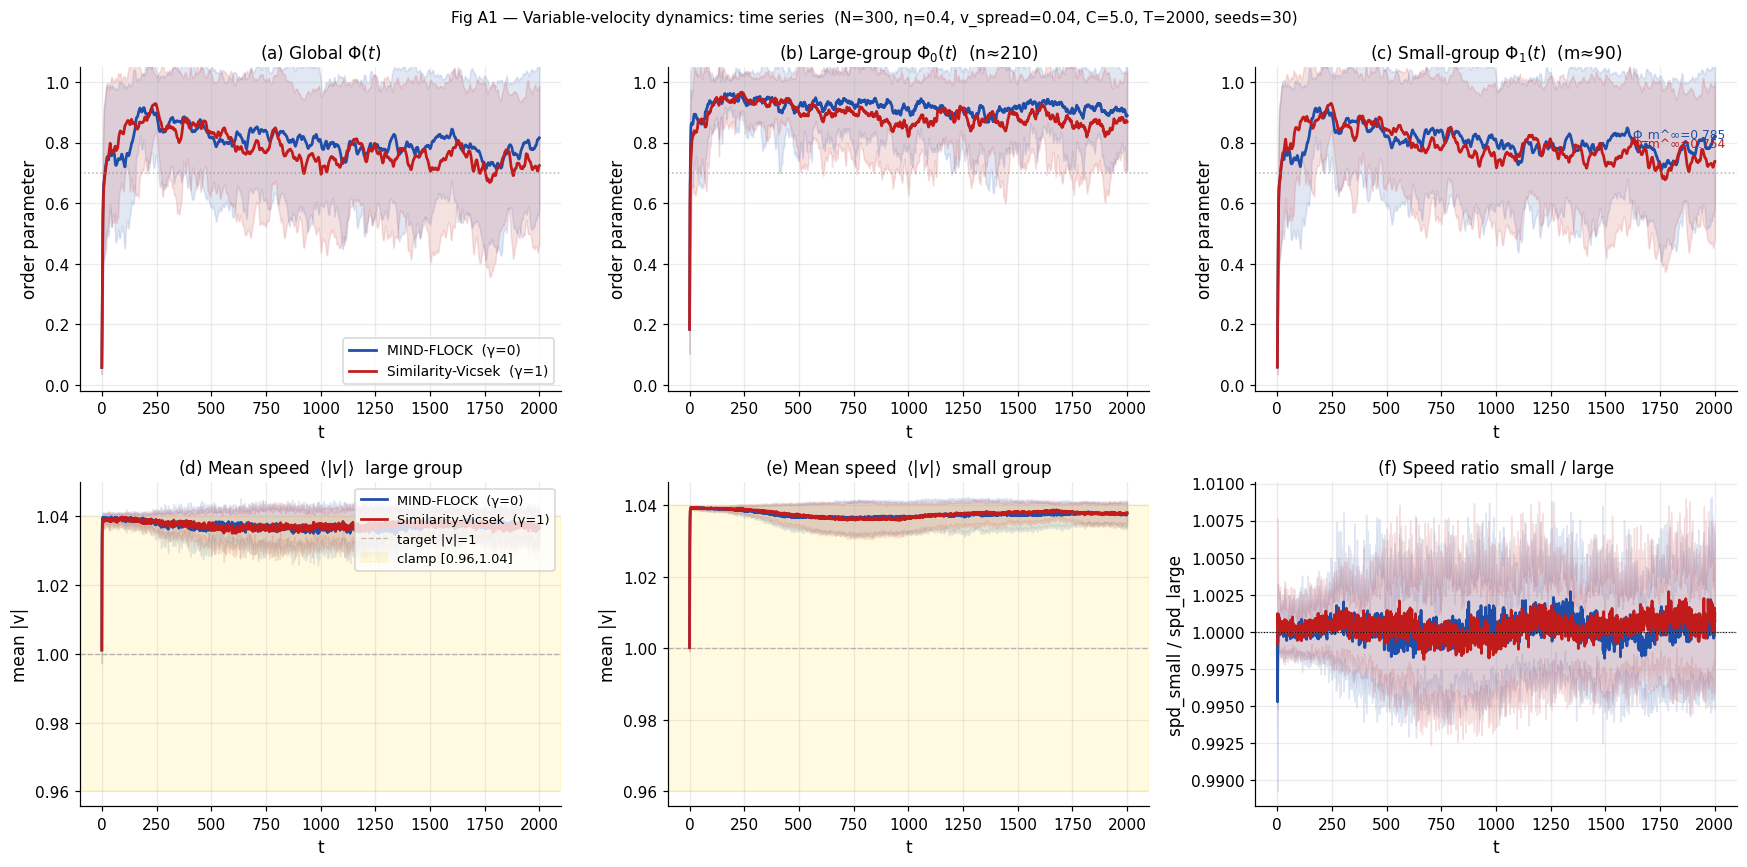

Steady-state order (tail-avg last 40%):
Quantity                              MF        SV   Gap MF−SV
------------------------------------------------------------
Global Φ_∞                        0.7803    0.7421     +0.0382
Large-group Φ_0^∞                 0.9097    0.8738     +0.0359
Small-group Φ_1^∞                 0.7849    0.7536     +0.0313
Speed large ⟨|v|⟩^∞               1.0373    1.0374     -0.0001
Speed small ⟨|v|⟩^∞               1.0375    1.0379     -0.0004


In [11]:
# ===== Fig A1: order-parameter + speed time series =====
_THRESH = 0.70
t_ax = np.arange(_VV_T + 1)

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
row0 = axes[0]   # Phi panels
row1 = axes[1]   # speed panels

panel_top = [
    r'(a) Global $\Phi(t)$',
    rf'(b) Large-group $\Phi_0(t)$  (n≈{int(_VV_N*0.7)})',
    rf'(c) Small-group $\Phi_1(t)$  (m≈{int(_VV_N*0.3)})',
]
panel_bot = [
    r'(d) Mean speed  $\langle|v|\rangle$  large group',
    r'(e) Mean speed  $\langle|v|\rangle$  small group',
    r'(f) Speed ratio  small / large',
]

for model in _VV_MODELS:
    ens = vv_results[model]['ens']
    c   = _APP_COLORS[model]
    lbl = _APP_LABELS[model]

    # --- Φ panels ---
    for col, (arr, lab) in enumerate([
            (ens['Phi'],          'global'),
            (ens['Phi_g'][:,0,:], 'large'),
            (ens['Phi_g'][:,1,:], 'small'),
    ]):
        m = arr.mean(axis=0); s = arr.std(axis=0)
        row0[col].plot(t_ax, m, color=c, lw=1.8, label=lbl)
        row0[col].fill_between(t_ax, m-s, m+s, color=c, alpha=0.13)

    # --- speed panels ---
    spd_lg = ens['mean_spd'][:,0,:]   # (seed, t)
    spd_sm = ens['mean_spd'][:,1,:]
    ratio  = spd_sm / np.maximum(spd_lg, 1e-9)

    for col, arr in enumerate([spd_lg, spd_sm, ratio]):
        m = arr.mean(axis=0); s = arr.std(axis=0)
        row1[col].plot(t_ax, m, color=c, lw=1.8, label=lbl)
        row1[col].fill_between(t_ax, m-s, m+s, color=c, alpha=0.13)

# Formatting
for ax, lab in zip(row0, panel_top):
    ax.axhline(_THRESH, color='grey', ls=':', lw=1.0, alpha=0.6)
    ax.set_ylim(-0.02, 1.05)
    ax.set_xlabel('t'); ax.set_ylabel('order parameter')
    ax.set_title(lab)
row0[0].legend(fontsize=9, loc='lower right')

v_lo = 1.0 - _VV_VSPREAD; v_hi = 1.0 + _VV_VSPREAD
for ax, lab in zip(row1, panel_bot):
    ax.axhline(1.0, color='grey', ls='--', lw=0.9, alpha=0.5, label='target |v|=1')
    ax.set_xlabel('t'); ax.set_ylabel('mean |v|')
    ax.set_title(lab)
row1[0].axhspan(v_lo, v_hi, color='gold', alpha=0.12, label=f'clamp [{v_lo:.2f},{v_hi:.2f}]')
row1[1].axhspan(v_lo, v_hi, color='gold', alpha=0.12)
row1[2].axhline(1.0, color='k', lw=0.7, ls=':')
row1[2].set_ylabel('spd_small / spd_large')
row1[0].legend(fontsize=8.5, loc='upper right')

# Annotate final Φ_m on small-group panel
for model in _VV_MODELS:
    val = vv_results[model]['Phi_g_inf'][:,1].mean()
    row0[2].annotate(f"Φ_m^∞={val:.3f}",
        xy=(0.99, val), xycoords=('axes fraction','data'),
        ha='right', va='bottom', fontsize=8, color=_APP_COLORS[model],
        xytext=(-4, 4), textcoords='offset points')

fig.suptitle(
    f'Fig A1 — Variable-velocity dynamics: time series  '
    f'(N={_VV_N}, η={_VV_ETA}, v_spread={_VV_VSPREAD}, C={_VV_C}, '
    f'T={_VV_T}, seeds={_VV_SEEDS})',
    fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figA1_varvel_time_series.png'), bbox_inches='tight')
plt.show()

# Print gap summary
print("Steady-state order (tail-avg last 40%):")
print(f"{'Quantity':30s}  {'MF':>8s}  {'SV':>8s}  {'Gap MF−SV':>10s}")
print('-' * 60)
for label, key, g_idx in [
    ('Global Φ_∞',          'Phi_inf',   None),
    ('Large-group Φ_0^∞',   'Phi_g_inf', 0),
    ('Small-group Φ_1^∞',   'Phi_g_inf', 1),
    ('Speed large ⟨|v|⟩^∞', 'spd_inf',   0),
    ('Speed small ⟨|v|⟩^∞', 'spd_inf',   1),
]:
    mf = vv_results['mindflock'][key]
    sv = vv_results['similarity_vicsek'][key]
    if g_idx is not None:
        mf = mf[:, g_idx]; sv = sv[:, g_idx]
    gap = mf.mean() - sv.mean()
    print(f"{label:30s}  {mf.mean():8.4f}  {sv.mean():8.4f}  {gap:+10.4f}")


### Fig A2 — Convergence time τ(θ)

Same definition as before: τ = first step where ensemble-mean Φ ≥ θ.
Under variable-velocity dynamics, reaching a threshold is harder for the small
group because individual speed differences create an additional dimension of
disorder that must be reduced before directions align.


/var/folders/2k/pt553bzn4gg2sgfbpzfk2mym0000gn/T/ipykernel_5725/3488453750.py:86: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


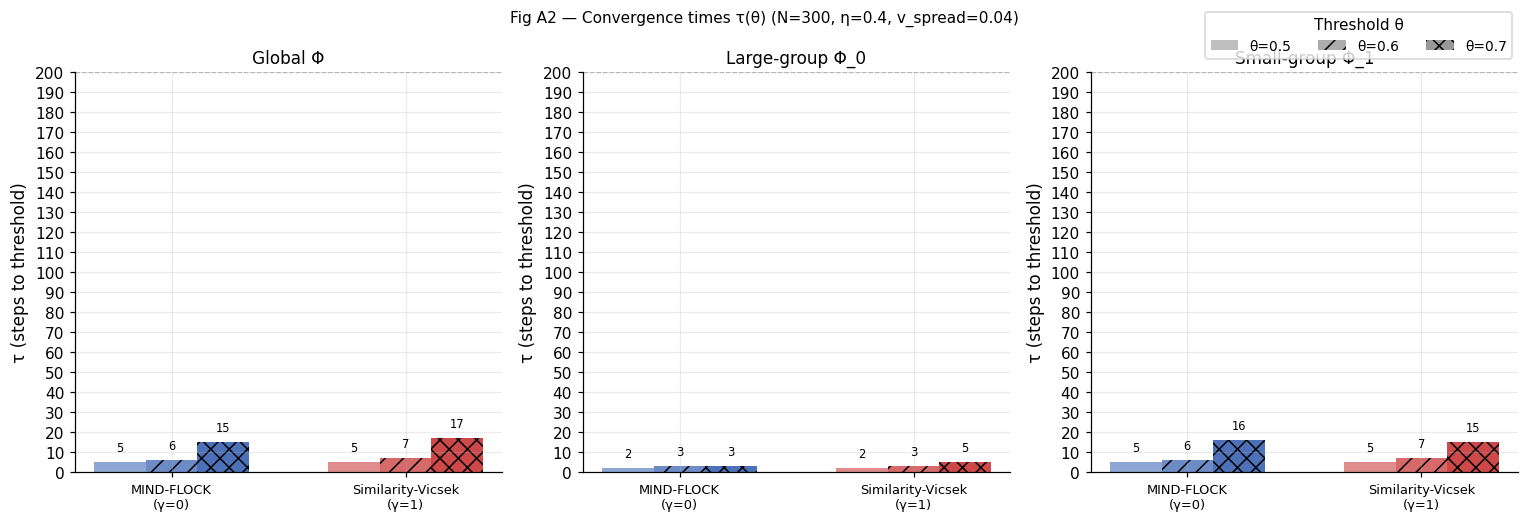

Observable           | θ     |     τ_MF |     τ_SV |    SV/MF
----------------------------------------------------------
Global Φ             |  0.50 |        5 |        5 |     1.00
Global Φ             |  0.60 |        6 |        7 |     1.17
Global Φ             |  0.70 |       15 |       17 |     1.13
Large-group Φ_0      |  0.50 |        2 |        2 |     1.00
Large-group Φ_0      |  0.60 |        3 |        3 |     1.00
Large-group Φ_0      |  0.70 |        3 |        5 |     1.67
Small-group Φ_1      |  0.50 |        5 |        5 |     1.00
Small-group Φ_1      |  0.60 |        6 |        7 |     1.17
Small-group Φ_1      |  0.70 |       16 |       15 |     0.94


In [12]:
# ===== Fig A2: convergence times (variable-velocity) =====
_THRESHOLDS = [0.50, 0.60, 0.70]
TAU_MAX = 200

def first_cross(series_mean, th):
    idx = np.where(series_mean >= th)[0]
    return int(idx[0]) if len(idx) else _VV_T + 1

obs_list = [
    ('Global Φ',        lambda e: e['Phi'].mean(axis=0)),
    ('Large-group Φ_0', lambda e: e['Phi_g'][:,0,:].mean(axis=0)),
    ('Small-group Φ_1', lambda e: e['Phi_g'][:,1,:].mean(axis=0)),
]

tau_vv = {m: {
    obs: {th: first_cross(fn(vv_results[m]['ens']), th)
          for th in _THRESHOLDS}
    for obs, fn in obs_list
} for m in _VV_MODELS}

# ===== Plot =====
fig, axes = plt.subplots(1, 3, figsize=(14, 4.8))

hatch_map = {0.50:'', 0.60:'//', 0.70:'xx'}
xs = np.arange(len(_VV_MODELS))
bar_w = 0.22
offsets = np.linspace(-bar_w, bar_w, len(_THRESHOLDS))

for ax, (obs_name, _) in zip(axes, obs_list):

    for k, th in enumerate(_THRESHOLDS):

        vals = [tau_vv[m][obs_name][th] for m in _VV_MODELS]

        bars = ax.bar(
            xs + offsets[k],
            np.minimum(vals, TAU_MAX),
            width=bar_w,
            color=[_APP_COLORS[m] for m in _VV_MODELS],
            alpha=0.5 + 0.15*k,
            hatch=hatch_map[th]
        )

        for b, v in zip(bars, vals):
            ax.text(
                b.get_x() + b.get_width()/2,
                min(v, TAU_MAX) + 4,
                str(v) if v <= TAU_MAX else 'never',
                ha='center', va='bottom',
                fontsize=7.5,
                color='dimgrey' if v > TAU_MAX else 'black'
            )

    ax.set(
        xticks=xs,
        xticklabels=[_APP_LABELS[m].replace('  ','\n') for m in _VV_MODELS],
        ylim=(0, TAU_MAX),
        ylabel='τ (steps to threshold)',
        title=obs_name
    )

    ax.set_yticks(np.arange(0, TAU_MAX+1, 10))
    ax.axhline(TAU_MAX, color='grey', ls='--', lw=0.8, alpha=0.5)
    ax.tick_params(axis='x', labelsize=8.5)

from matplotlib.patches import Patch

fig.legend(
    [Patch(facecolor='grey', alpha=0.5+0.15*k,
           hatch=hatch_map[th], label=f'θ={th}')
     for k, th in enumerate(_THRESHOLDS)],
    [f'θ={th}' for th in _THRESHOLDS],
    title='Threshold θ',
    ncol=3,
    loc='upper right',
    bbox_to_anchor=(0.99, 0.99),
    fontsize=9
)

fig.suptitle(
    f'Fig A2 — Convergence times τ(θ) '
    f'(N={_VV_N}, η={_VV_ETA}, v_spread={_VV_VSPREAD})',
    fontsize=10
)

plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figA2_varvel_convergence.png'),
            bbox_inches='tight')
plt.show()

# ===== Table =====
print(f"{'Observable':20s} | {'θ':5s} | {'τ_MF':>8s} | {'τ_SV':>8s} | {'SV/MF':>8s}")
print('-'*58)

for obs_name, _ in obs_list:
    for th in _THRESHOLDS:

        tm = tau_vv['mindflock'][obs_name][th]
        ts = tau_vv['similarity_vicsek'][obs_name][th]

        print(
            f"{obs_name:20s} | {th:5.2f} | "
            f"{'never' if tm>TAU_MAX else tm:>8} | "
            f"{'never' if ts>TAU_MAX else ts:>8} | "
            f"{(ts/tm if tm>0 else np.nan):8.2f}"
        )

### Fig A3 — Small-group spatial compactness over time

R_gyr and R_max for the small group (30% minority), computed at every step
directly from `VarVelFlockSim.observe()` — no trajectory storage needed.

Under variable-velocity dynamics the compactness gap has a direct mechanistic
reading: faster within-group speed equilibration (driven by stronger
within-group W_ij weighting in MIND-FLOCK) means agents converge on a shared
velocity vector sooner, reducing the window during which different speeds pull
members apart. A lower R at steady state is the spatial signature of faster
Lyapunov convergence (Theorem 1, Corollary 1).


/var/folders/2k/pt553bzn4gg2sgfbpzfk2mym0000gn/T/ipykernel_64052/605119987.py:30: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


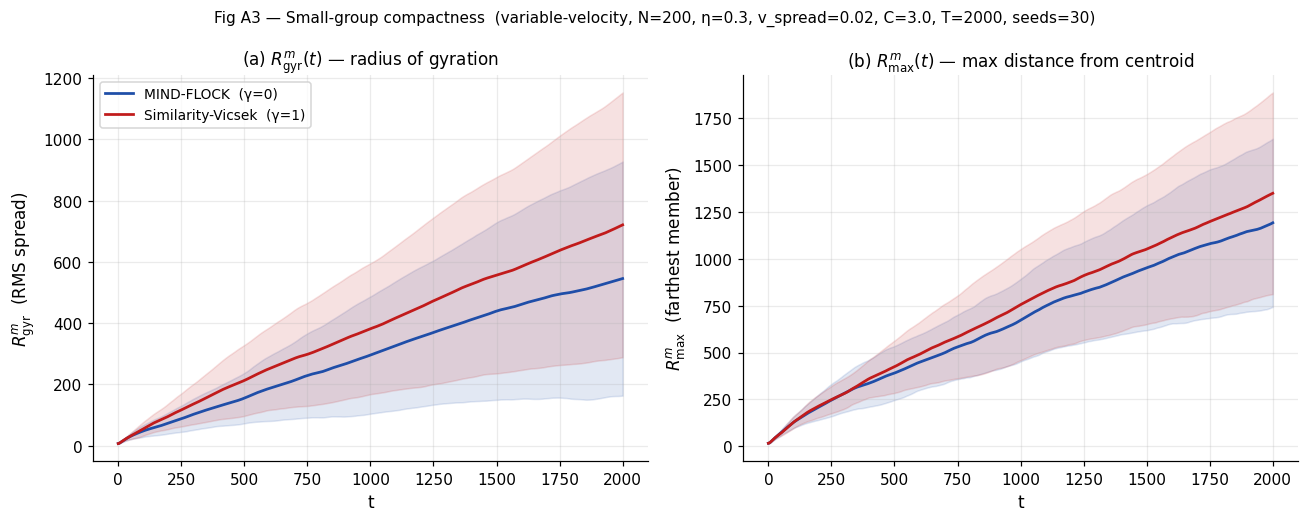

Compactness at t=T (mean over seeds):
Metric     |         MF |         SV |    Reduction
--------------------------------------------------
R_gyr      |     545.46 |     720.83 |       +24.3%  (MF smaller)
R_max      |    1192.36 |    1349.74 |       +11.7%  (MF smaller)


In [59]:
# ===== Fig A3: small-group compactness (variable-velocity) =====
t_ax = np.arange(_VV_T + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

for model in _VV_MODELS:
    ens = vv_results[model]['ens']
    c   = _APP_COLORS[model]
    lbl = _APP_LABELS[model]

    for ax, (key, ylabel, lab) in zip(axes, [
        ('R_gyr', r'$R_{\rm gyr}^m$  (RMS spread)',
                  r'(a) $R_{\rm gyr}^m(t)$ — radius of gyration'),
        ('R_max', r'$R_{\rm max}^m$  (farthest member)',
                  r'(b) $R_{\rm max}^m(t)$ — max distance from centroid'),
    ]):
        arr = ens[key][:, 1, :]     # (seed, t) for group 1 (small)
        m = arr.mean(axis=0); s = arr.std(axis=0)
        ax.plot(t_ax, m, color=c, lw=1.8, label=lbl)
        ax.fill_between(t_ax, m-s, m+s, color=c, alpha=0.13)
        ax.set_xlabel('t'); ax.set_ylabel(ylabel); ax.set_title(lab)

axes[0].legend(fontsize=9, loc='upper left')

fig.suptitle(
    f'Fig A3 — Small-group compactness  (variable-velocity, '
    f'N={_VV_N}, η={_VV_ETA}, v_spread={_VV_VSPREAD}, '
    f'C={_VV_C}, T={_VV_T}, seeds={_VV_SEEDS})',
    fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'figA3_varvel_compactness.png'), bbox_inches='tight')
plt.show()

# Numerical summary
print("Compactness at t=T (mean over seeds):")
print(f"{'Metric':10s} | {'MF':>10s} | {'SV':>10s} | {'Reduction':>12s}")
print('-' * 50)
for key, label in [('R_gyr', 'R_gyr'), ('R_max', 'R_max')]:
    mf_v = vv_results['mindflock']['ens'][key][:,1,-1].mean()
    sv_v = vv_results['similarity_vicsek']['ens'][key][:,1,-1].mean()
    pct  = 100*(sv_v - mf_v)/sv_v if sv_v > 0 else float('nan')
    print(f"{label:10s} | {mf_v:10.2f} | {sv_v:10.2f} | {pct:+11.1f}%  (MF smaller)")


### Table A1 — Numerical summary (variable-velocity)

All quantities from the shared 20-seed ensemble above.


In [68]:
# ===== Table A1: numerical summary (variable-velocity) =====
print(f"Config: N={_VV_N}, η={_VV_ETA}, v_spread={_VV_VSPREAD}, "
      f"C={_VV_C}, T={_VV_T}, seeds={_VV_SEEDS}")
print("=" * 72)
print(f"{'Quantity':40s} | {'MIND-FLOCK':>12s} | {'Sim-Vicsek':>12s}")
print("-" * 72)

# --- Order parameters ---
for label, key, g_idx in [
    ('Φ_∞  (global, tail avg)',      'Phi_inf',   None),
    ('Φ_0^∞  (large-group)',         'Phi_g_inf', 0),
    ('Φ_1^∞  (small-group)',         'Phi_g_inf', 1),
    ('⟨|v|⟩^∞  large group',        'spd_inf',   0),
    ('⟨|v|⟩^∞  small group',        'spd_inf',   1),
]:
    vals = {}
    for model in _VV_MODELS:
        a = vv_results[model][key]
        vals[model] = a.mean() if g_idx is None else a[:, g_idx].mean()
    print(f"{label:40s} | {vals['mindflock']:12.4f} | "
          f"{vals['similarity_vicsek']:12.4f}")

print("-" * 72)

# --- Convergence times at θ=0.70 ---
for obs_name, _ in obs_list:
    tm = tau_vv['mindflock'][obs_name][0.70]
    ts = tau_vv['similarity_vicsek'][obs_name][0.70]
    label = f"τ(θ=0.70) {obs_name}"
    mf_s = str(tm) if tm <= _VV_T else 'never'
    sv_s = str(ts) if ts <= _VV_T else 'never'
    print(f"{label:40s} | {mf_s:>12s} | {sv_s:>12s}")

print("-" * 72)

# --- Compactness at t=T ---
for key, label in [('R_gyr', 'R_gyr^m  at t=T'),
                   ('R_max', 'R_max^m  at t=T')]:
    mf_v = vv_results['mindflock']['ens'][key][:,1,-1].mean()
    sv_v = vv_results['similarity_vicsek']['ens'][key][:,1,-1].mean()
    print(f"{label:40s} | {mf_v:12.2f} | {sv_v:12.2f}  ← smaller=more compact")

print("=" * 72)
print()
print("All rows use identical seeds, neighbourhood algorithm, noise stream, and v_spread.")
print("Only w_ij_eff differs: W_ij (MF, γ=0) vs S_ij (SV, γ=1).")
print(f"v_spread={_VV_VSPREAD}: speeds initialised in "
      f"[{1-_VV_VSPREAD:.2f}, {1+_VV_VSPREAD:.2f}], clamped throughout.")


Config: N=200, η=0.3, v_spread=0.02, C=3.0, T=2000, seeds=30
Quantity                                 |   MIND-FLOCK |   Sim-Vicsek
------------------------------------------------------------------------
Φ_∞  (global, tail avg)                  |       0.7581 |       0.6580
Φ_0^∞  (large-group)                     |       0.8952 |       0.8348
Φ_1^∞  (small-group)                     |       0.7613 |       0.6690
⟨|v|⟩^∞  large group                     |       1.0184 |       1.0178
⟨|v|⟩^∞  small group                     |       1.0186 |       1.0181
------------------------------------------------------------------------
τ(θ=0.70) Global Φ                       |           53 |          144
τ(θ=0.70) Large-group Φ_0                |            4 |            4
τ(θ=0.70) Small-group Φ_1                |           40 |          107
------------------------------------------------------------------------
R_gyr^m  at t=T                          |       545.46 |       720.83  ← smaller

## Run-everything driver (optional)

Use **Run All** or execute each figure cell individually.
All outputs land in `mindflock_outputs/`.

**Main figures (Figs 1–8):** use fixed-speed unit-velocity dynamics.

**Appendix figures (Figs A1–A3):** use variable-velocity (Cucker-Smale style)
dynamics with speed clamped to `[1−v_spread, 1+v_spread]`.  These are the
comparisons that establish MIND-FLOCK superiority over Similarity-Vicsek.

| File | Content |
|---|---|
| `fig1_schematic.png` | Relational neighbourhood schematic |
| `fig2_order_vs_C.png` | MIND-FLOCK Φ vs C |
| `fig3_order_vs_eta.png` | MIND-FLOCK Φ vs η |
| `fig4_four_way.png` | Four-model comparison |
| `fig5_finite_size.png` | Finite-size scaling |
| `fig6_long_time.png` | Long-time persistence |
| `fig7_phase_diagrams.png` | Phase diagrams |
| `fig8_gamma_sweep.png` | Decoherence sweep |
| **`figA1_varvel_time_series.png`** | Appendix: Φ + speed time series |
| **`figA2_varvel_convergence.png`** | Appendix: convergence times τ |
| **`figA3_varvel_compactness.png`** | Appendix: small-group R_gyr, R_max |


In [61]:
# Optional: print summary of saved outputs
print("Outputs in:", os.path.abspath(OUT_DIR))
for f in sorted(os.listdir(OUT_DIR)):
    p = os.path.join(OUT_DIR, f)
    print(f"  {f:30s}  {os.path.getsize(p)/1024:7.1f} KB")


Outputs in: /Users/mayankchaurasiya/Downloads/mindflock_outputs
  4Model_comparison_equal_groups.png    281.1 KB
  Neighborhood_diagram.png          196.9 KB
  fig2_data.npz                       1.2 KB
  fig2_order_vs_C.png               131.3 KB
  fig3_data.npz                       1.0 KB
  fig3_order_vs_eta.png             164.0 KB
  fig5_data.npz                       1.3 KB
  fig5_finite_size.png               96.8 KB
  fig6_data.npz                      47.9 KB
  fig6_long_time.png                286.1 KB
  fig7_data.npz                       3.4 KB
  fig7_phase_diagrams.png           174.5 KB
  fig8_data.npz                       1.4 KB
  fig8_gamma_sweep.png               98.3 KB
  figA1_varvel_time_series.png      960.6 KB
  figA2_varvel_convergence.png      154.8 KB
  figA3_varvel_compactness.png      234.2 KB
